# Fine-Tuning LLMs for Bug Detection in Quantum Software

**Course:** CSC 7644 — Applied LLM Development, Louisiana State University  
**Author:** Md Saidur Rahman (`mrahm65@lsu.edu`)  
**Date:** May 2026

---

## Comparative Study Design

This notebook reports a controlled three-way comparison of pre-trained encoders that share architecture, parameter count, and training protocol. Any observed performance differences can therefore be attributed to **pre-training data**, not to model capacity or architectural choices.

| # | Model | Pre-training Corpus | Variable Isolated |
|---|---|---|---|
| 1 | `roberta-base` | Natural language only | Effect of *no* code-aware pre-training (control) |
| 2 | `microsoft/codebert-base` | Code + natural language (bimodal) | Effect of code-aware pre-training |
| 3 | `microsoft/graphcodebert-base` | Code + natural language + data-flow graphs | Effect of structure-aware pre-training |

## Evaluation Protocol

Each backbone is evaluated under **stratified 5-fold cross-validation repeated across 5 independent random seeds**, yielding 25 fold-runs per backbone (75 fold-runs total). All folds, hyperparameters, and random seeds are held identical across the three backbones to ensure direct comparability.


## Section 1 — Environment Setup and Dependency Installation

In [1]:
import subprocess, sys
subprocess.run([
    sys.executable, '-m', 'pip', 'install', '-q',
    'transformers==4.44.2', 'datasets==2.21.0',
    'scikit-learn==1.5.2', 'accelerate==0.34.2',
], check=True)
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 83.1 MB/s eta 0:00:00
Done.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.6.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


## Section 2 — Library Imports and Compute Device Verification

In [2]:
%matplotlib inline
import json, os, random, gc, shutil, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold

# Note: EarlyStoppingCallback intentionally removed — replaced by ManualEarlyStoppingCallback
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    TrainerCallback, set_seed,
)
from datasets import Dataset
import transformers
transformers.logging.set_verbosity_error()

# Clean academic plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 13,
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 13,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})
PALETTE = {'classical': '#e74c3c', 'quantum': '#2980b9', 'mean': '#2c3e50'}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
if device == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

2026-05-08 03:02:06.894293: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778209327.090590      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778209327.151167      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778209327.630761      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778209327.630797      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778209327.630800      57 computation_placer.cc:177] computation placer alr

Device: cuda
GPU: Tesla T4


## Section 3 — Experimental Configuration

The configuration block below specifies all training and cross-validation hyperparameters used uniformly across the three backbones.

In [3]:
# ── Update this path to match your Kaggle dataset ─────────────────────────
DATA_PATH = '/kaggle/input/datasets/saidurlsu/classical-vs-quantum/bug_patterns_categorized.json'
# ──────────────────────────────────────────────────────────────────────────

# ── Model registry: three RoBERTa-architecture encoders, 125M params each ─
MODEL_REGISTRY = [
    {
        'name'        : 'roberta-base',
        'short'       : 'roberta',
        'description' : 'General-purpose text encoder (English only) — no code pretraining',
    },
    {
        'name'        : 'microsoft/codebert-base',
        'short'       : 'codebert',
        'description' : 'Code + NL bimodal pretraining (CodeSearchNet)',
    },
    {
        'name'        : 'microsoft/graphcodebert-base',
        'short'       : 'graphcodebert',
        'description' : 'Code + NL + data-flow graph pretraining',
    },
]

MAX_LEN      = 256
N_FOLDS      = 5
CV_SEEDS     = [42, 7, 2024, 99, 123]   # 5 seeds → 25 fold-runs per model

NUM_EPOCHS   = 12
LR           = 2e-5
BATCH_SIZE   = 8
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.15
DROPOUT      = 0.2
VAL_SPLIT    = 0.10
ES_PATIENCE  = 4

label_list = ['classical', 'quantum']
label2id   = {l: i for i, l in enumerate(label_list)}
id2label   = {i: l for l, i in label2id.items()}
NUM_LABELS = 2

print('Models to compare:')
for m in MODEL_REGISTRY:
    print(f'  • {m["short"]:<14s}  ({m["name"]})')
print(f'CV protocol: {N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {N_FOLDS*len(CV_SEEDS)} folds per model')
print(f'Total fold-runs: {N_FOLDS*len(CV_SEEDS)*len(MODEL_REGISTRY)}')


Models to compare:
  • roberta         (roberta-base)
  • codebert        (microsoft/codebert-base)
  • graphcodebert   (microsoft/graphcodebert-base)
CV protocol: 5-fold × 5 seeds = 25 folds per model
Total fold-runs: 75


## Section 4 — Dataset Loading and Class Distribution Inspection

In [4]:
with open(DATA_PATH) as f:
    raw_data = json.load(f)

labeled = [x for x in raw_data if x.get('bug_category') in ('quantum', 'classical')]

n_classical = sum(1 for x in labeled if x['bug_category'] == 'classical')
n_quantum   = sum(1 for x in labeled if x['bug_category'] == 'quantum')

print(f'Total loaded   : {len(raw_data)}')
print(f'Labeled        : {len(labeled)}')
print(f'  classical    : {n_classical}  ({100*n_classical/len(labeled):.1f}%)')
print(f'  quantum      : {n_quantum}    ({100*n_quantum/len(labeled):.1f}%)')
print(f'Imbalance ratio: {n_classical/n_quantum:.2f}:1')

Total loaded   : 233
Labeled        : 233
  classical    : 134  (57.5%)
  quantum      : 99    (42.5%)
Imbalance ratio: 1.35:1


## Section 5 — Input Construction and Text Encoding

Each bug report is converted to a single textual input by concatenating the `name`, `description`, and `example_code` fields. Inputs are tokenized at evaluation time using the appropriate tokenizer for each backbone.

In [5]:
def to_text(item):
    name = (item.get('name') or '').strip()
    desc = (item.get('description') or '').strip()
    code = (item.get('example_code') or '').strip()
    return '\n'.join(p for p in [name, desc, code] if p)

real_texts  = np.array([to_text(x) for x in labeled])
real_labels = np.array([label2id[x['bug_category']] for x in labeled])

print(f'Samples         : {len(real_texts)}')
print(f'Avg text length : {np.mean([len(t) for t in real_texts]):.0f} chars')

Samples         : 233
Avg text length : 225 chars


## Section 6 — Custom Training Components

This section defines three custom components used during training:

1. **`ManualEarlyStoppingCallback`** — A monitor for macro-F1 with patience-based termination, designed to operate without checkpoint saving (avoiding Kaggle's 19.5 GB disk-quota limit).  
2. **`EpochLogCallback`** — A lightweight callback that captures per-epoch validation loss and accuracy for learning-curve analysis.  
3. **`WeightedTrainer`** — A subclass of HuggingFace's `Trainer` that applies class-weighted cross-entropy loss with label smoothing to mitigate the 57.5 / 42.5 class imbalance, supplemented by minority oversampling at the dataset level.

In [6]:
class ManualEarlyStoppingCallback(TrainerCallback):
    """
    Early stopping on macro-F1 that works with save_strategy='no'.
    Replaces HuggingFace EarlyStoppingCallback which requires
    load_best_model_at_end=True (and therefore checkpoint saving).
    """
    def __init__(self, patience=4):
        self.patience = patience
        self.best_f1  = -1.0
        self.wait     = 0

    def on_train_begin(self, args, state, control, **kwargs):
        # Reset state at the start of each fold
        self.best_f1 = -1.0
        self.wait    = 0

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        current_f1 = metrics.get('eval_f1_macro', 0.0) if metrics else 0.0
        if current_f1 > self.best_f1 + 1e-4:
            self.best_f1 = current_f1
            self.wait    = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                control.should_training_stop = True


class EpochLogCallback(TrainerCallback):
    """Stores per-epoch val metrics for learning curve plotting."""
    def __init__(self, log_store):
        self.log_store = log_store

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.log_store.append({
                'epoch'    : state.epoch,
                'eval_loss': metrics.get('eval_loss',     float('nan')),
                'eval_acc' : metrics.get('eval_accuracy', float('nan')),
                'eval_f1'  : metrics.get('eval_f1_macro', float('nan')),
            })


class WeightedTrainer(Trainer):
    """Trainer with class-weighted CE + label smoothing."""
    def set_class_weights(self, weights):
        self._class_weights = weights.to(self.args.device)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=getattr(self, '_class_weights', None),
            label_smoothing=0.05,
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def oversample_to_balance(texts, labels, rng):
    """Duplicate minority-class samples until all classes are equal size."""
    by = defaultdict(list)
    for t, y in zip(texts, labels):
        by[y].append(t)
    max_n = max(len(v) for v in by.values())
    out_t, out_y = [], []
    for y, ts in by.items():
        reps = max_n // len(ts)
        rem  = max_n - reps * len(ts)
        expanded = ts * reps + (rng.sample(ts, rem) if rem else [])
        out_t.extend(expanded)
        out_y.extend([y] * len(expanded))
    idx = list(range(len(out_t)))
    rng.shuffle(idx)
    return [out_t[i] for i in idx], [out_y[i] for i in idx]


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'   : accuracy_score(labels, preds),
        'f1_macro'   : f1_score(labels, preds, average='macro',    zero_division=0),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
    }


print('Callbacks and helpers defined.')

Callbacks and helpers defined.


## Section 7 — Single-Fold Training Procedure

The `run_fold` function executes one cross-validation fold for a given backbone. It accepts `model_name`, `tokenizer`, and `data_collator` as parameters so that the identical training procedure is applied to all three backbones, ensuring comparability.

In [7]:
def run_fold(train_texts, train_labels, test_texts, test_labels, seed, output_dir,
             model_name, tokenizer, data_collator):
    """Train on one CV fold for the given backbone.

    Returns (y_true, y_pred, probs, metrics, epoch_log).
    """
    set_seed(seed)
    rng = random.Random(seed)

    # Balance training set
    train_texts, train_labels = oversample_to_balance(train_texts, train_labels, rng)

    # Stratified val split
    tr_t, val_t, tr_y, val_y = train_test_split(
        train_texts, train_labels,
        test_size=VAL_SPLIT, random_state=seed,
        stratify=train_labels if len(set(train_labels)) > 1 else None,
    )

    # Tokenize with the *current* tokenizer (each backbone has its own)
    def tokenize(batch):
        return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

    train_ds = Dataset.from_dict({'text': tr_t,  'labels': tr_y}).map(tokenize, batched=True)
    val_ds   = Dataset.from_dict({'text': val_t, 'labels': val_y}).map(tokenize, batched=True)
    test_ds  = Dataset.from_dict(
        {'text': list(test_texts), 'labels': list(test_labels)}
    ).map(tokenize, batched=True)

    config = AutoConfig.from_pretrained(
        model_name, num_labels=NUM_LABELS,
        id2label=id2label, label2id=label2id,
        hidden_dropout_prob=DROPOUT,
        attention_probs_dropout_prob=DROPOUT,
        ignore_mismatched_sizes=True,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config, ignore_mismatched_sizes=True,
    )

    # Inverse-frequency class weights
    cnt  = Counter(tr_y)
    freq = np.array([cnt.get(i, 1) for i in range(NUM_LABELS)], dtype=np.float32)
    cw   = torch.tensor(freq.sum() / (NUM_LABELS * freq), dtype=torch.float)

    epoch_log = []

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=64,
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        # ── DISK FIX: no checkpoint saving ────────────────────────────
        save_strategy='no',
        load_best_model_at_end=False,
        # ──────────────────────────────────────────────────────────────
        logging_steps=500,
        report_to='none',
        seed=seed,
        fp16=(device == 'cuda'),
        disable_tqdm=True,
    )

    trainer = WeightedTrainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        tokenizer=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            ManualEarlyStoppingCallback(patience=ES_PATIENCE),
            EpochLogCallback(epoch_log),
        ],
    )
    trainer.set_class_weights(cw)
    trainer.train()

    # Predict on held-out test fold
    pred   = trainer.predict(test_ds)
    y_true = pred.label_ids
    y_pred = np.argmax(pred.predictions, axis=-1)
    probs  = torch.softmax(torch.tensor(pred.predictions), dim=-1).numpy()

    metrics = {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'f1_macro'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc'    : roc_auc_score(y_true, probs[:, 1]),
    }

    # ── Cleanup: free GPU memory + delete temp files ───────────────────
    del trainer, model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir, ignore_errors=True)
    # ──────────────────────────────────────────────────────────────────

    return y_true, y_pred, probs, metrics, epoch_log


print('run_fold() defined.')


run_fold() defined.


## Section 8 — Full 25-Fold Experimental Runner

The `run_full_experiment` function orchestrates a complete 25-fold cross-validation cycle for one backbone. It manages tokenization, fold iteration, metric aggregation, and per-model figure generation. All artifacts are saved with a backbone-specific suffix (e.g., `fig1_confusion_matrix_codebert.png`) and persisted to disk as each model finishes, ensuring partial results are preserved if the kernel is interrupted.

In [8]:
def run_full_experiment(model_name, model_short, description=''):
    """Run 25-fold CV for one backbone and save all artifacts.

    Returns a dict with aggregate results suitable for cross-model comparison.
    """
    print('\n' + '═' * 72)
    print(f'  EXPERIMENT: {model_short.upper()}')
    print(f'  Model     : {model_name}')
    print(f'  Notes     : {description}')
    print('═' * 72)

    # Load tokenizer for this backbone
    tokenizer     = AutoTokenizer.from_pretrained(model_name)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ── 25-fold CV loop ────────────────────────────────────────────────
    results_all    = []
    all_epoch_logs = []

    for repeat_idx, cv_seed in enumerate(CV_SEEDS):
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=cv_seed)
        print(f'\n=== {model_short} | Repeat {repeat_idx+1}/{len(CV_SEEDS)} (seed={cv_seed}) ===')

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(real_texts, real_labels)
        ):
            y_true, y_pred, probs, m, elog = run_fold(
                real_texts[train_idx].tolist(), real_labels[train_idx].tolist(),
                real_texts[test_idx].tolist(),  real_labels[test_idx].tolist(),
                seed=cv_seed * 100 + fold_idx,
                output_dir=f'/kaggle/working/tmp_{model_short}_{repeat_idx}_{fold_idx}',
                model_name=model_name,
                tokenizer=tokenizer,
                data_collator=data_collator,
            )
            results_all.append({
                'repeat' : repeat_idx, 'fold': fold_idx, 'cv_seed': cv_seed,
                'y_true' : y_true.tolist(), 'y_pred': y_pred.tolist(),
                'probs'  : probs.tolist(),
                **m,
            })
            all_epoch_logs.append(elog)
            print(f'  fold {fold_idx+1}/5 — '
                  f'acc={m["accuracy"]:.3f}  '
                  f'f1={m["f1_macro"]:.3f}  '
                  f'auc={m["roc_auc"]:.3f}  '
                  f'(n_test={len(test_idx)})')

    # ── Aggregate ────────────────────────────────────────────────────
    cv_df = pd.DataFrame([{
        'repeat'     : r['repeat'] + 1,
        'fold'       : r['fold'] + 1,
        'accuracy'   : r['accuracy'],
        'f1_macro'   : r['f1_macro'],
        'f1_weighted': r['f1_weighted'],
        'roc_auc'    : r['roc_auc'],
    } for r in results_all])

    print(f'\n--- {model_short} | aggregate (mean ± std across {len(results_all)} folds) ---')
    agg = cv_df[['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc']].agg(['mean', 'std'])
    print(agg.round(3))

    # Pooled
    y_true_all = np.concatenate([r['y_true'] for r in results_all])
    y_pred_all = np.concatenate([r['y_pred'] for r in results_all])
    probs_all  = np.concatenate([r['probs']  for r in results_all])
    acc_p = accuracy_score(y_true_all, y_pred_all)
    f1_p  = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    auc_p = roc_auc_score(y_true_all, probs_all[:, 1])

    fold_accs = np.array([r['accuracy'] for r in results_all])
    fold_f1s  = np.array([r['f1_macro'] for r in results_all])
    fold_aucs = np.array([r['roc_auc']  for r in results_all])

    # ── Figure 1: Confusion matrix ────────────────────────────────────
    cm     = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=label_list, yticklabels=label_list,
                cbar_kws={'label': 'Prediction count'},
                linewidths=0.5, linecolor='white', ax=ax)
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j + 0.5, i + 0.40, f'{cm[i,j]}',
                    ha='center', va='center', fontsize=18,
                    fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.62, f'({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=11, color=color)
    ax.set_xlabel('Predicted label', labelpad=8)
    ax.set_ylabel('True label', labelpad=8)
    ax.set_title(
        f'Pooled Confusion Matrix — {model_short.upper()}\n'
        f'{len(results_all)} cross-validation folds  |  '
        f'Accuracy = {acc_p:.3f}, Macro-F1 = {f1_p:.3f}, AUC = {auc_p:.3f}',
        fontsize=12, pad=10
    )
    ax.tick_params(axis='both', which='both', length=0)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig1_confusion_matrix_{model_short}.png', bbox_inches='tight')
    from IPython.display import display
    display(plt.gcf())
    plt.close('all')

    # ── Figure 2: Per-fold scatter (3 metrics) ────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rng_j = np.random.RandomState(42)
    for ax, vals, label, color in [
        (axes[0], fold_accs, 'Accuracy',  '#e74c3c'),
        (axes[1], fold_f1s,  'Macro-F1',  '#2980b9'),
        (axes[2], fold_aucs, 'ROC-AUC',   '#27ae60'),
    ]:
        mean, std = vals.mean(), vals.std(ddof=1)
        jx = rng_j.uniform(-0.15, 0.15, len(vals))
        ax.axhspan(mean - std, mean + std, alpha=0.12, color=color,
                   label=f'±1 std ({std:.3f})')
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5,
                   label='Random (50%)')
        ax.axhline(mean, color=PALETTE['mean'], linestyle='--',
                   linewidth=2, label=f'Mean = {mean:.3f}')
        ax.scatter(jx, vals, s=60, color=color, alpha=0.75,
                   edgecolor='white', linewidth=0.5, zorder=3)
        ax.set_xlim(-0.5, 0.5); ax.set_ylim(0.2, 1.02)
        ax.set_xticks([]); ax.set_ylabel(label)
        ax.set_title(f'{label} — {len(vals)} folds', fontweight='bold')
        ax.legend(fontsize=10, loc='lower right')
    fig.suptitle(
        f'Per-Fold Performance Distribution — {model_short.upper()}\n'
        f'Stratified 5-fold cross-validation × 5 random seeds (n = {len(vals)} folds)',
        fontsize=13, y=1.02
    )
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig2_fold_distribution_{model_short}.png', bbox_inches='tight')
    display(plt.gcf())
    plt.close('all')

    # ── Figure 3: ROC curve ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    base_fpr = np.linspace(0, 1, 200)
    tprs = []
    for r in results_all:
        fpr, tpr, _ = roc_curve(r['y_true'], np.array(r['probs'])[:, 1])
        tprs.append(np.interp(base_fpr, fpr, tpr))
        ax.plot(base_fpr, tprs[-1], color='#2980b9', alpha=0.10, linewidth=0.8)
    tprs     = np.array(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0, ddof=1)
    ax.fill_between(base_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                    color='#2980b9', alpha=0.20, label='±1 std band')
    ax.plot(base_fpr, mean_tpr, color='#2980b9', linewidth=2.5,
            label=f'Mean ROC (AUC = {auc_p:.3f})')
    ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
            linewidth=1.5, label='Random classifier')
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(
        f'Receiver Operating Characteristic — {model_short.upper()}\n'
        f'Mean AUC = {auc_p:.3f} pooled across {len(results_all)} cross-validation folds',
        fontsize=12
    )
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=11, loc='lower right')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig3_roc_curve_{model_short}.png', bbox_inches='tight')
    display(plt.gcf())
    plt.close('all')

    # ── Figure 4: Learning curves (val loss + val accuracy) ──────────
    # Aggregate per-epoch metrics across all folds
    max_ep = max(len(elog) for elog in all_epoch_logs)
    losses_by_epoch = [[] for _ in range(max_ep)]
    accs_by_epoch   = [[] for _ in range(max_ep)]
    for elog in all_epoch_logs:
        for ep_idx, entry in enumerate(elog):
            losses_by_epoch[ep_idx].append(entry['eval_loss'])
            accs_by_epoch[ep_idx].append(entry['eval_acc'])

    epochs_x  = np.arange(1, max_ep + 1)
    loss_mean = np.array([np.nanmean(v) if v else np.nan for v in losses_by_epoch])
    loss_std  = np.array([np.nanstd(v, ddof=1) if len(v) > 1 else 0 for v in losses_by_epoch])
    acc_mean  = np.array([np.nanmean(v) if v else np.nan for v in accs_by_epoch])
    acc_std   = np.array([np.nanstd(v, ddof=1) if len(v) > 1 else 0 for v in accs_by_epoch])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: Validation loss
    ax = axes[0]
    ax.fill_between(epochs_x, loss_mean - loss_std, loss_mean + loss_std,
                    alpha=0.18, color='#e74c3c', label='Mean ± 1 std')
    ax.plot(epochs_x, loss_mean, color='#e74c3c', linewidth=2.5,
            marker='o', markersize=6, label='Mean validation loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation loss')
    ax.set_xticks(epochs_x)
    ax.set_title(f'Validation Loss per Epoch\n(mean ± 1 SD across {len(results_all)} CV folds)',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    # Right: Validation accuracy
    ax = axes[1]
    ax.fill_between(epochs_x, acc_mean - acc_std, acc_mean + acc_std,
                    alpha=0.18, color='#2980b9', label='Mean ± 1 std')
    ax.plot(epochs_x, acc_mean, color='#2980b9', linewidth=2.5,
            marker='o', markersize=6, label='Mean validation accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation accuracy')
    ax.set_xticks(epochs_x)
    ax.set_title(f'Validation Accuracy per Epoch\n(mean ± 1 SD across {len(results_all)} CV folds)',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)

    fig.suptitle(f'Training Dynamics — {model_short.upper()}',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/fig4_learning_curves_{model_short}.png',
                bbox_inches='tight')
    display(plt.gcf())
    plt.close('all')

    # ── Save results JSON for this model ─────────────────────────────
    with open(f'/kaggle/working/results_{model_short}.json', 'w') as f:
        json.dump({
            'task'            : 'classical_vs_quantum_binary',
            'model'           : model_name,
            'model_short'     : model_short,
            'description'     : description,
            'n_samples'       : len(labeled),
            'cv_setup'        : f'{N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {len(results_all)} folds',
            'mean_accuracy'   : float(agg.loc['mean', 'accuracy']),
            'std_accuracy'    : float(agg.loc['std',  'accuracy']),
            'mean_f1_macro'   : float(agg.loc['mean', 'f1_macro']),
            'std_f1_macro'    : float(agg.loc['std',  'f1_macro']),
            'mean_roc_auc'    : float(agg.loc['mean', 'roc_auc']),
            'std_roc_auc'     : float(agg.loc['std',  'roc_auc']),
            'pooled_accuracy' : float(acc_p),
            'pooled_f1_macro' : float(f1_p),
            'pooled_roc_auc'  : float(auc_p),
            'cv_results'      : results_all,
        }, f, indent=2, default=str)
    cv_df.to_csv(f'/kaggle/working/per_fold_{model_short}.csv', index=False)

    # ── Cleanup tokenizer to free RAM before next model ──────────────
    del tokenizer, data_collator
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

    # Return aggregate summary for cross-model comparison
    return {
        'model_name'    : model_name,
        'model_short'   : model_short,
        'description'   : description,
        'fold_accs'     : fold_accs.tolist(),
        'fold_f1s'      : fold_f1s.tolist(),
        'fold_aucs'     : fold_aucs.tolist(),
        'mean_accuracy' : float(fold_accs.mean()),
        'std_accuracy'  : float(fold_accs.std(ddof=1)),
        'mean_f1_macro' : float(fold_f1s.mean()),
        'std_f1_macro'  : float(fold_f1s.std(ddof=1)),
        'mean_roc_auc'  : float(fold_aucs.mean()),
        'std_roc_auc'   : float(fold_aucs.std(ddof=1)),
        'pooled_accuracy': float(acc_p),
        'pooled_f1_macro': float(f1_p),
        'pooled_roc_auc' : float(auc_p),
        'epoch_logs'    : all_epoch_logs,
        'y_true_all'    : y_true_all.tolist(),
        'y_pred_all'    : y_pred_all.tolist(),
        'probs_all'     : probs_all.tolist(),
    }


print('run_full_experiment() defined.')


run_full_experiment() defined.


## Section 9 — Execution of Three-Backbone Comparative Study

This section iterates over the model registry and invokes `run_full_experiment` for each backbone. Per-model artifacts (figures, classification reports, JSON summaries) are written to `/kaggle/working/` upon completion of each backbone, ensuring incremental persistence of results.


════════════════════════════════════════════════════════════════════════
  EXPERIMENT: ROBERTA
  Model     : roberta-base
  Notes     : General-purpose text encoder (English only) — no code pretraining
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.692366361618042, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1753, 'eval_samples_per_second': 125.479, 'eval_steps_per_second': 5.704, 'epoch': 1.0}
{'eval_loss': 0.6873236298561096, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.5809523809523809, 'eval_f1_weighted': 0.580952380952381, 'eval_runtime': 0.1785, 'eval_samples_per_second': 123.28, 'eval_steps_per_second': 5.604, 'epoch': 2.0}
{'eval_loss': 0.6778233051300049, 'eval_accuracy': 0.7727272727272727, 'eval_f1_macro': 0.7603485838779956, 'eval_f1_weighted': 0.7603485838779956, 'eval_runtime': 0.1747, 'eval_samples_per_second': 125.958, 'eval_steps_per_second': 5.725, 'epoch': 3.0}
{'eval_loss': 0.584658682346344, 'eval_accuracy': 0.7272727272727273, 'eval_f1_macro': 0.7053571428571428, 'eval_f1_weighted': 0.7053571428571428, 'eval_runtime': 0.1765, 'eval_samples_per_second': 124.68, 'eval_steps_per_second': 5.667, 'epoch': 4.0}
{'ev

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6939404010772705, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1659, 'eval_samples_per_second': 132.586, 'eval_steps_per_second': 6.027, 'epoch': 1.0}
{'eval_loss': 0.691495954990387, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5831578947368421, 'eval_f1_weighted': 0.5831578947368421, 'eval_runtime': 0.1662, 'eval_samples_per_second': 132.384, 'eval_steps_per_second': 6.017, 'epoch': 2.0}
{'eval_loss': 0.686150848865509, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1653, 'eval_samples_per_second': 133.083, 'eval_steps_per_second': 6.049, 'epoch': 3.0}
{'eval_loss': 0.6743155717849731, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.6239316239316239, 'eval_f1_weighted': 0.6239316239316239, 'eval_runtime': 0.1656, 'eval_samples_per_second': 132.838, 'eval_steps_per_second': 6.038, 'epoch': 4.0}
{

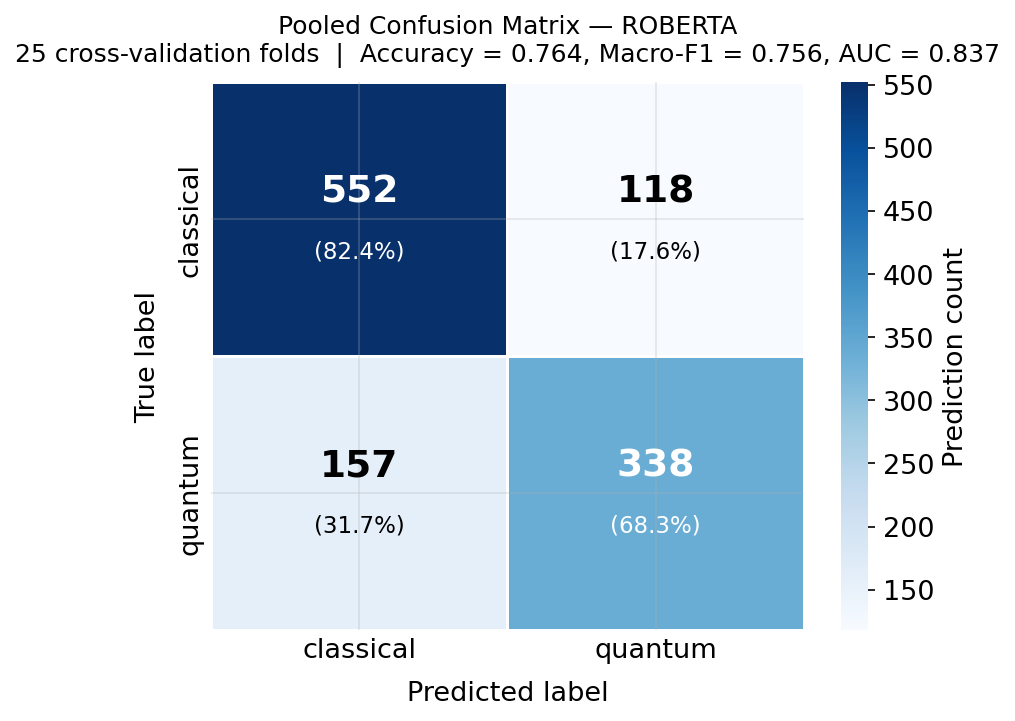

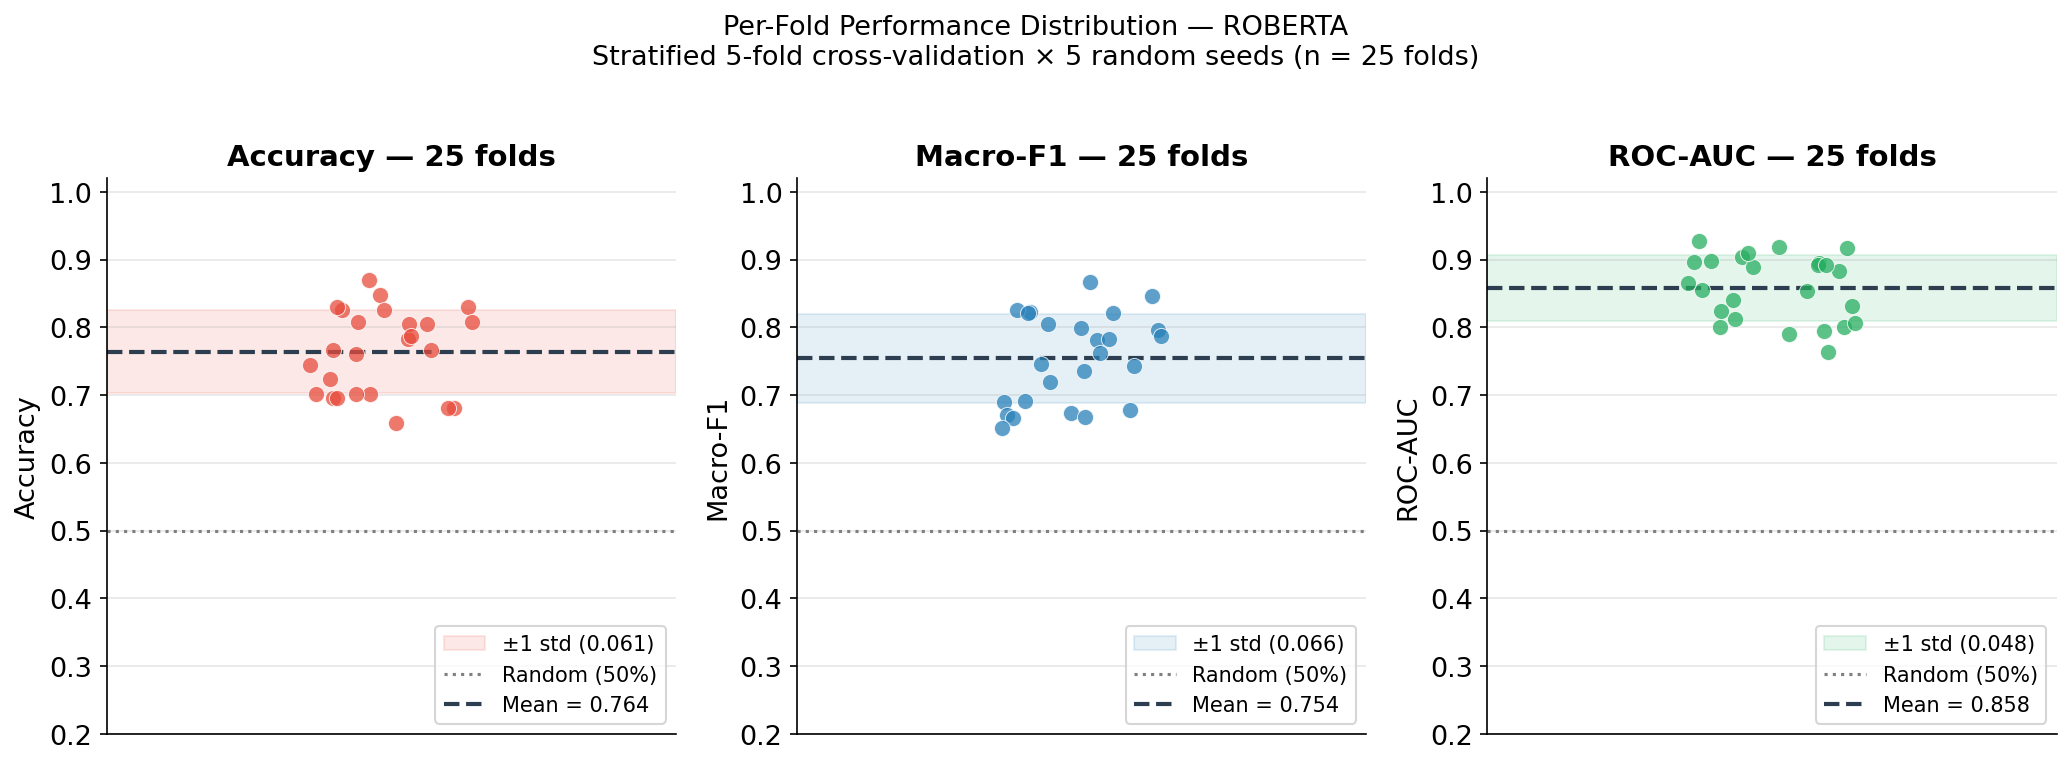

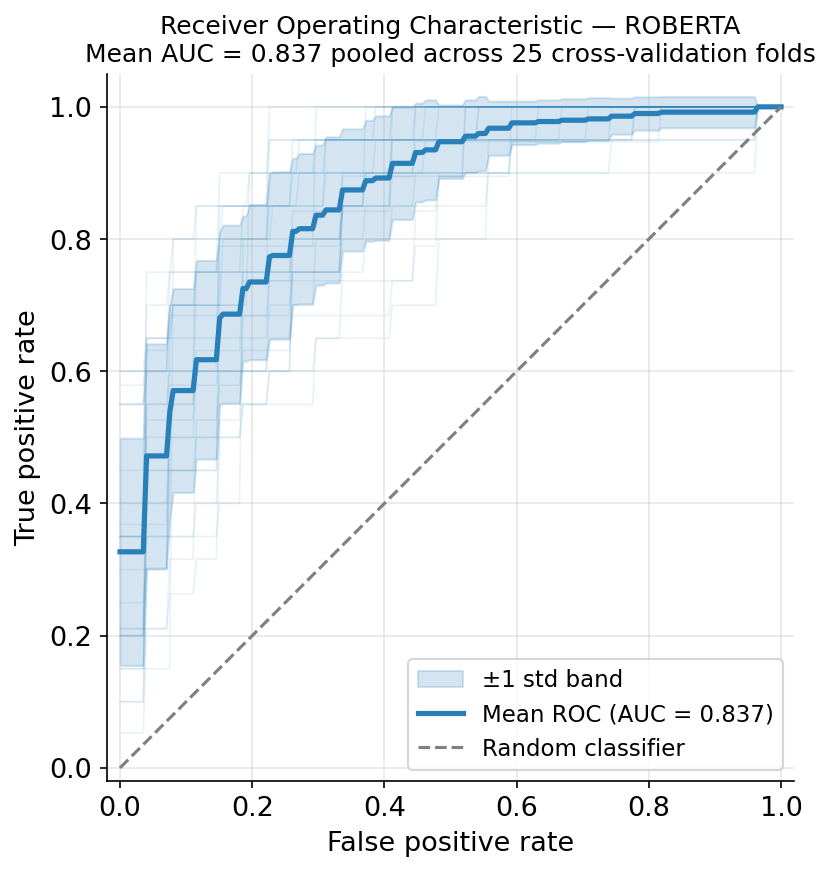

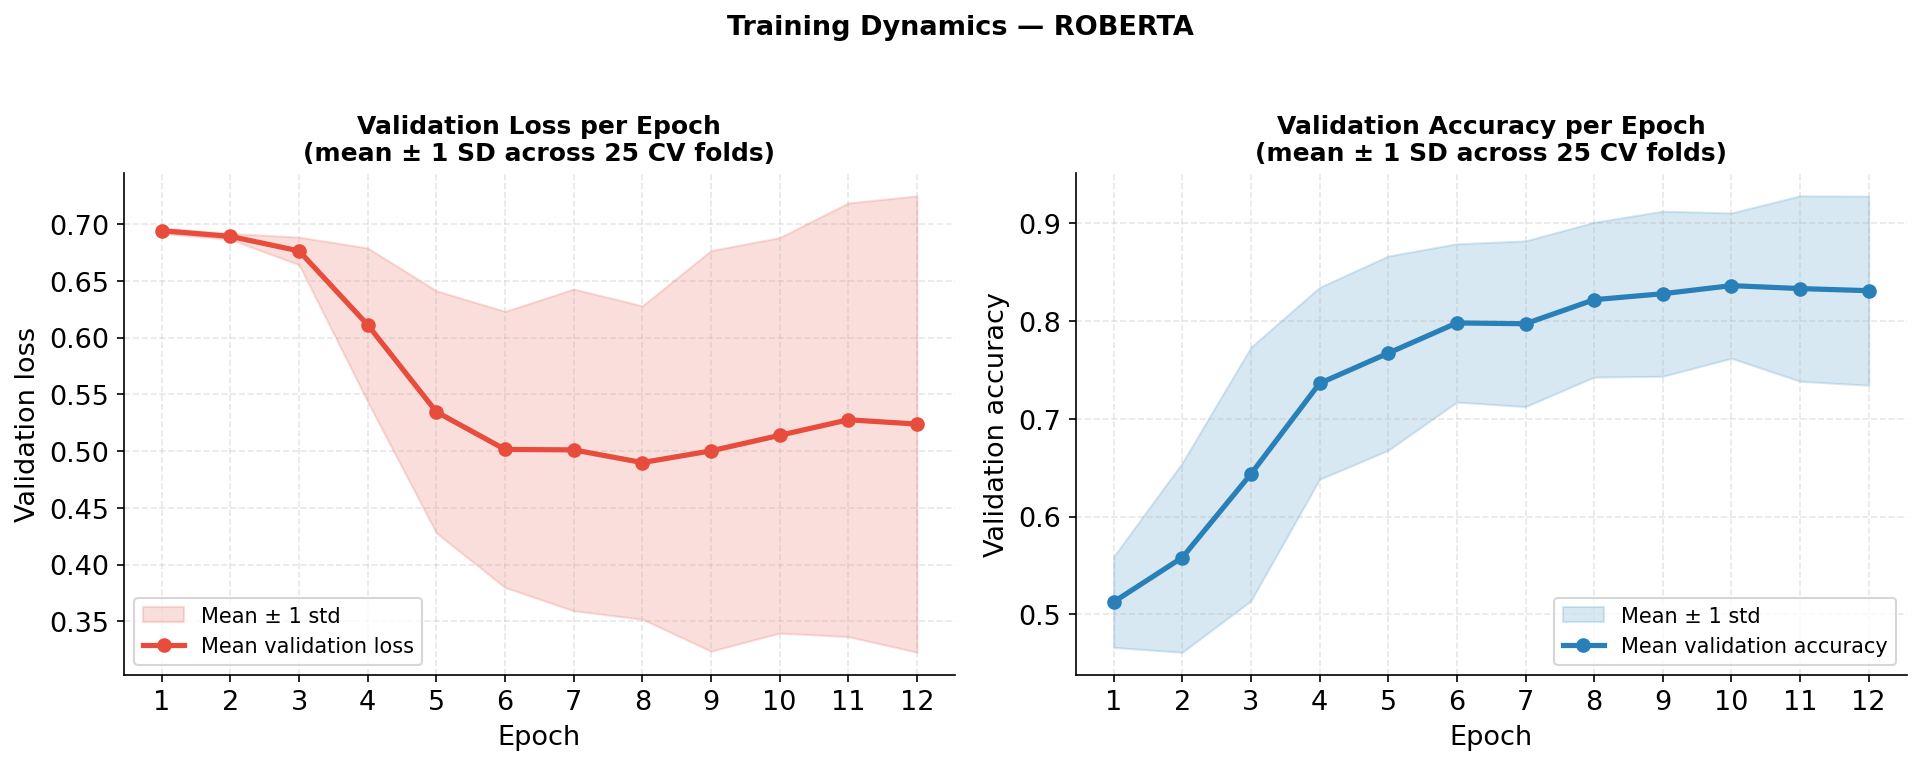


✔ Completed: roberta (acc=0.764, f1=0.754, auc=0.858)

════════════════════════════════════════════════════════════════════════
  EXPERIMENT: CODEBERT
  Model     : microsoft/codebert-base
  Notes     : Code + NL bimodal pretraining (CodeSearchNet)
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.6980964541435242, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1753, 'eval_samples_per_second': 125.52, 'eval_steps_per_second': 5.705, 'epoch': 1.0}
{'eval_loss': 0.6830748319625854, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1771, 'eval_samples_per_second': 124.207, 'eval_steps_per_second': 5.646, 'epoch': 2.0}
{'eval_loss': 0.6733648777008057, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1775, 'eval_samples_per_second': 123.966, 'eval_steps_per_second': 5.635, 'epoch': 3.0}
{'eval_loss': 0.6447546482086182, 'eval_accuracy': 0.6818181818181818, 'eval_f1_macro': 0.6644880174291938, 'eval_f1_weighted': 0.6644880174291938, 'eval_runtime': 0.1773, 'eval_samples_per_second': 124.116, 'eval_steps_per_second': 5.642, 'epoch': 4.0}
{'eval_loss': 0

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6970739364624023, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1631, 'eval_samples_per_second': 134.854, 'eval_steps_per_second': 6.13, 'epoch': 1.0}
{'eval_loss': 0.6917371153831482, 'eval_accuracy': 0.5, 'eval_f1_macro': 0.3333333333333333, 'eval_f1_weighted': 0.3333333333333333, 'eval_runtime': 0.1625, 'eval_samples_per_second': 135.418, 'eval_steps_per_second': 6.155, 'epoch': 2.0}
{'eval_loss': 0.6836774945259094, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1589, 'eval_samples_per_second': 138.424, 'eval_steps_per_second': 6.292, 'epoch': 3.0}
{'eval_loss': 0.6664634943008423, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5448275862068965, 'eval_f1_weighted': 0.5448275862068965, 'eval_runtime': 0.1681, 'eval_samples_per_second': 130.884, 'eval_steps_per_second': 5.949, 'epoch': 4.0}
{'eval_loss': 0

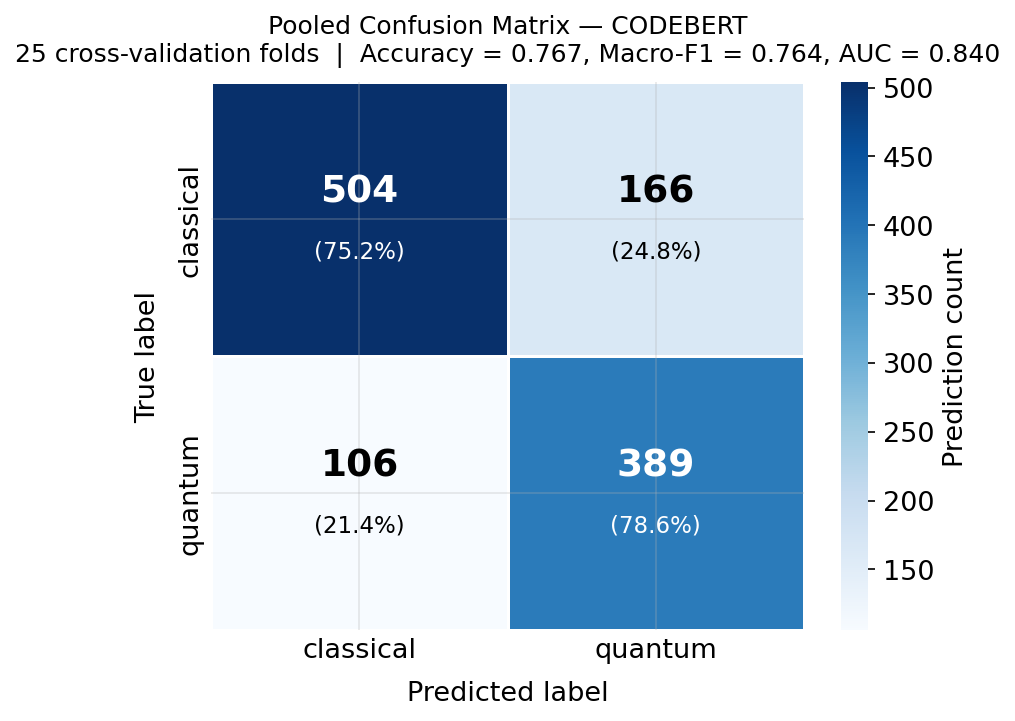

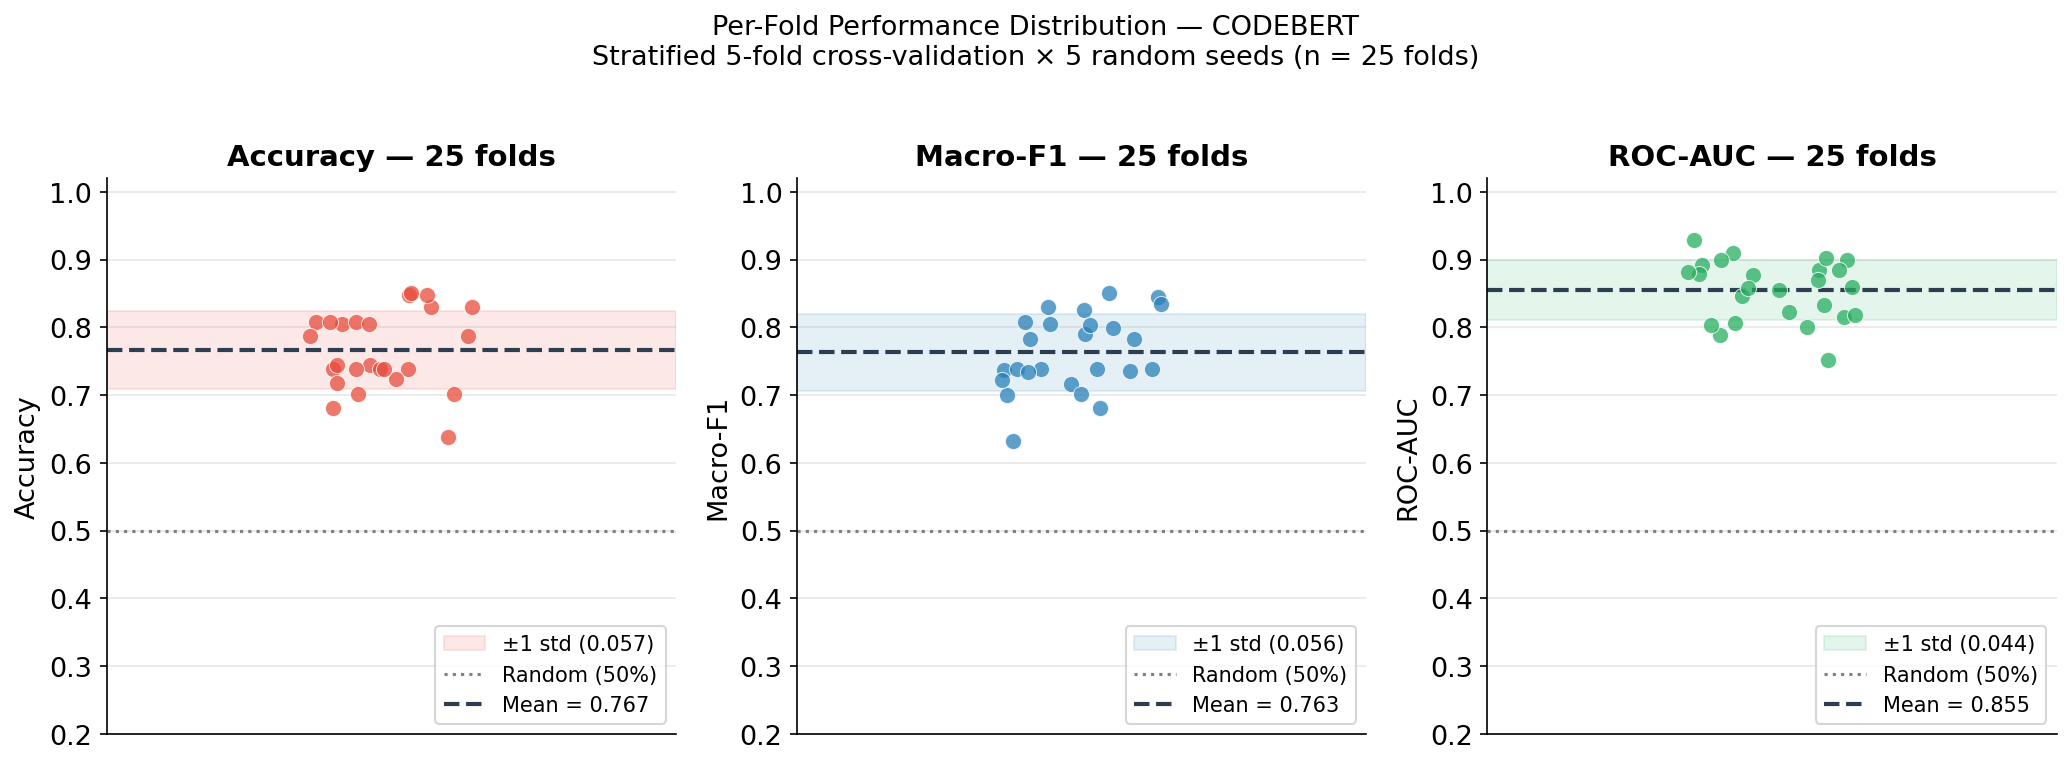

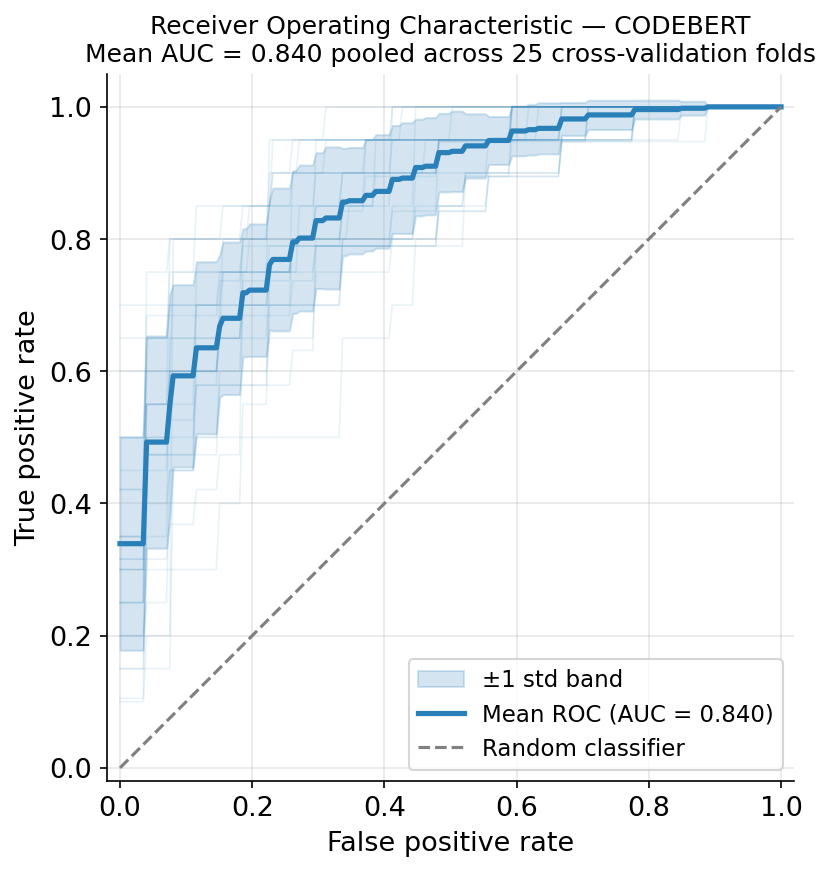

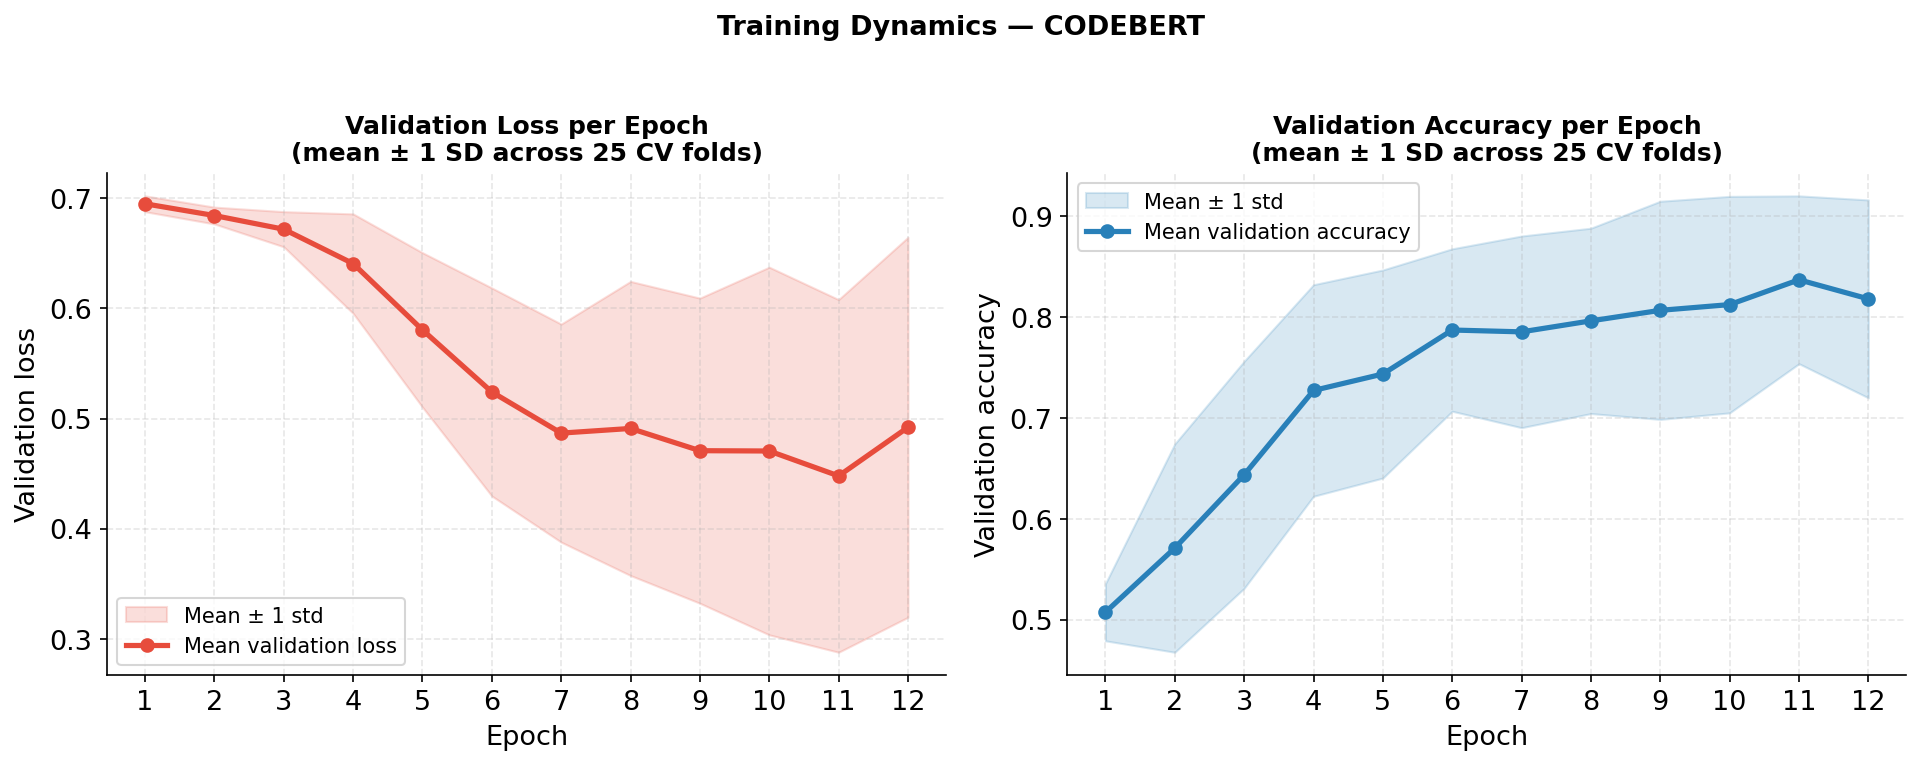


✔ Completed: codebert (acc=0.767, f1=0.763, auc=0.855)

════════════════════════════════════════════════════════════════════════
  EXPERIMENT: GRAPHCODEBERT
  Model     : microsoft/graphcodebert-base
  Notes     : Code + NL + data-flow graph pretraining
════════════════════════════════════════════════════════════════════════


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/539 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

{'eval_loss': 0.67970210313797, 'eval_accuracy': 0.5454545454545454, 'eval_f1_macro': 0.4270833333333333, 'eval_f1_weighted': 0.42708333333333337, 'eval_runtime': 0.172, 'eval_samples_per_second': 127.882, 'eval_steps_per_second': 5.813, 'epoch': 1.0}
{'eval_loss': 0.6483932733535767, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1737, 'eval_samples_per_second': 126.677, 'eval_steps_per_second': 5.758, 'epoch': 2.0}
{'eval_loss': 0.5955482721328735, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1739, 'eval_samples_per_second': 126.475, 'eval_steps_per_second': 5.749, 'epoch': 3.0}
{'eval_loss': 0.4984976649284363, 'eval_accuracy': 0.8636363636363636, 'eval_f1_macro': 0.8633540372670807, 'eval_f1_weighted': 0.8633540372670807, 'eval_runtime': 0.1752, 'eval_samples_per_second': 125.561, 'eval_steps_per_second': 5.707, 

Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/46 [00:00<?, ? examples/s]

{'eval_loss': 0.6927430629730225, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5448275862068965, 'eval_f1_weighted': 0.5448275862068965, 'eval_runtime': 0.164, 'eval_samples_per_second': 134.128, 'eval_steps_per_second': 6.097, 'epoch': 1.0}
{'eval_loss': 0.6842252016067505, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5086848635235732, 'eval_f1_weighted': 0.5086848635235732, 'eval_runtime': 0.1657, 'eval_samples_per_second': 132.733, 'eval_steps_per_second': 6.033, 'epoch': 2.0}
{'eval_loss': 0.6450275182723999, 'eval_accuracy': 0.5909090909090909, 'eval_f1_macro': 0.5686274509803921, 'eval_f1_weighted': 0.5686274509803921, 'eval_runtime': 0.1654, 'eval_samples_per_second': 133.022, 'eval_steps_per_second': 6.046, 'epoch': 3.0}
{'eval_loss': 0.6028373837471008, 'eval_accuracy': 0.6363636363636364, 'eval_f1_macro': 0.6071428571428572, 'eval_f1_weighted': 0.6071428571428572, 'eval_runtime': 0.1617, 'eval_samples_per_second': 136.038, 'eval_steps_per_second': 6.184,

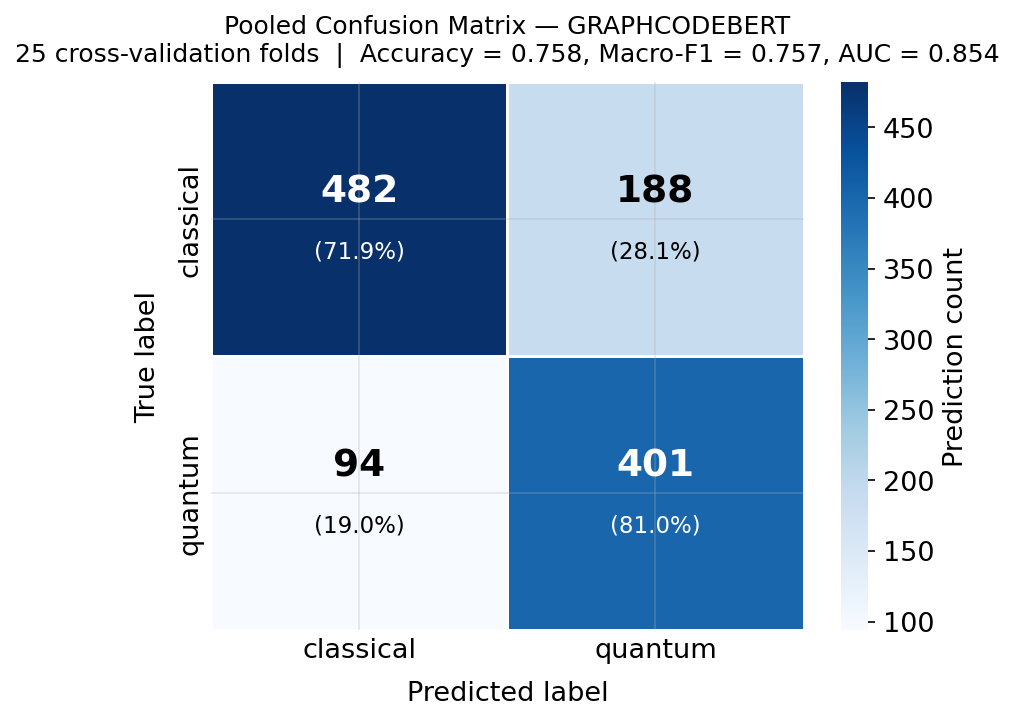

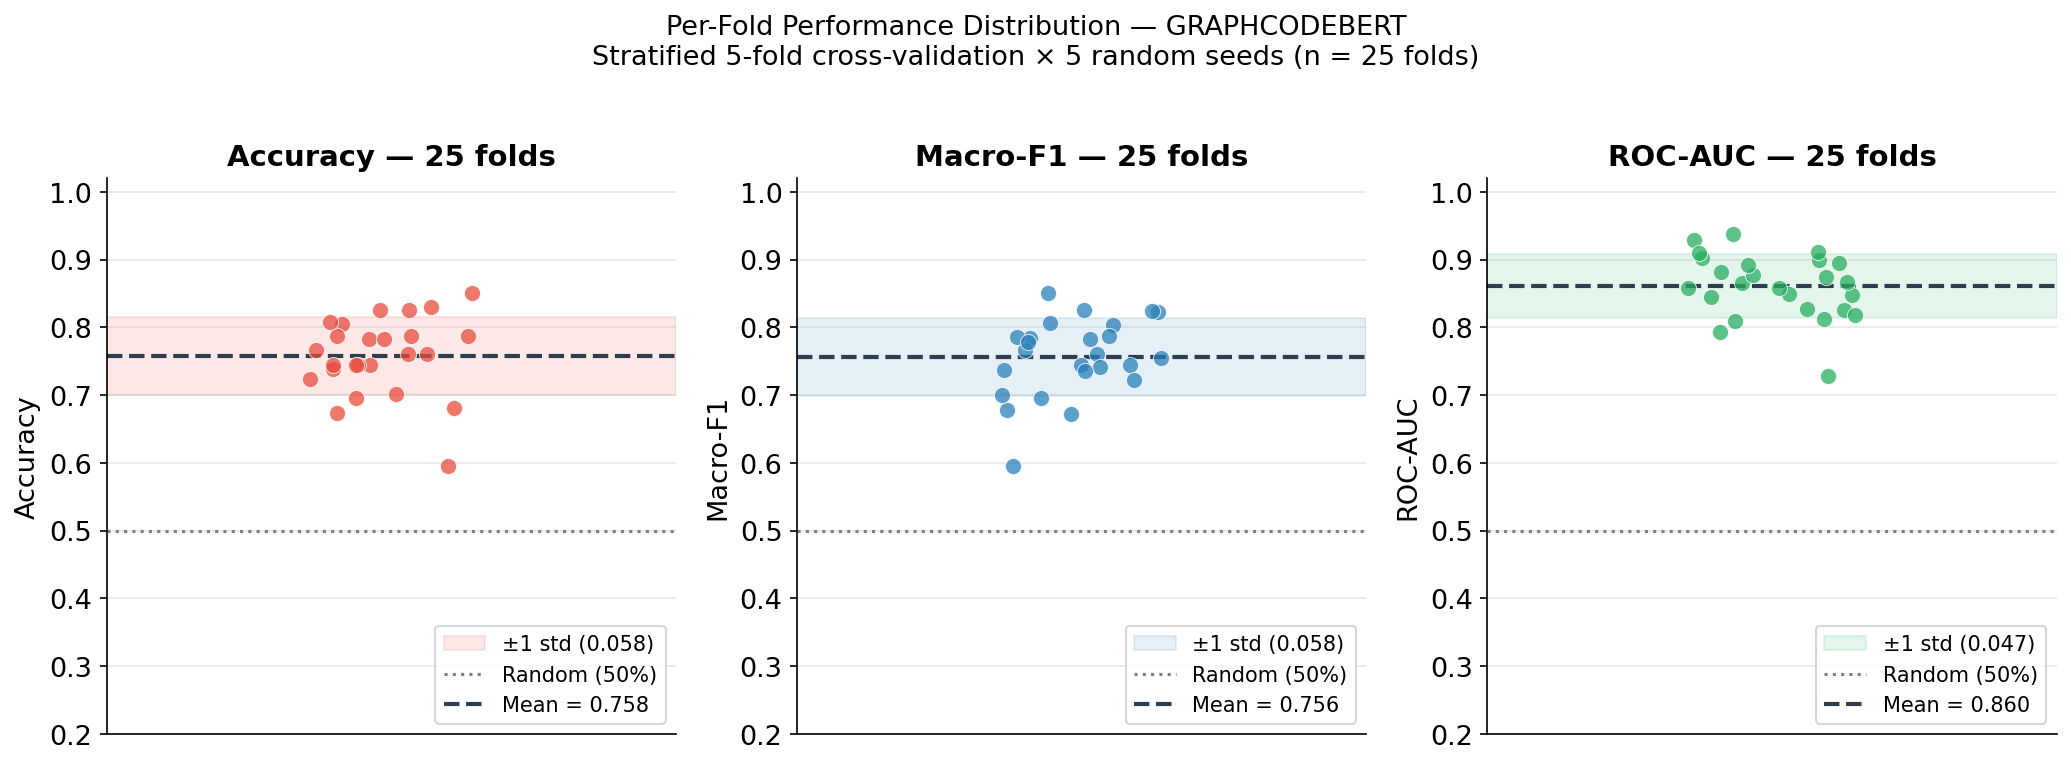

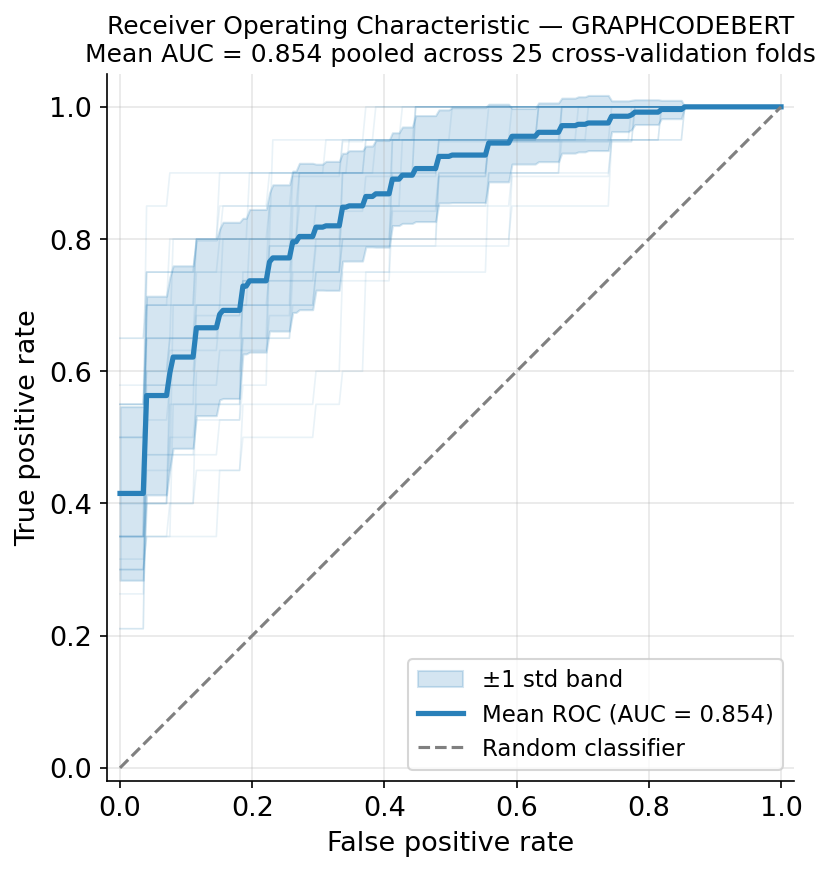

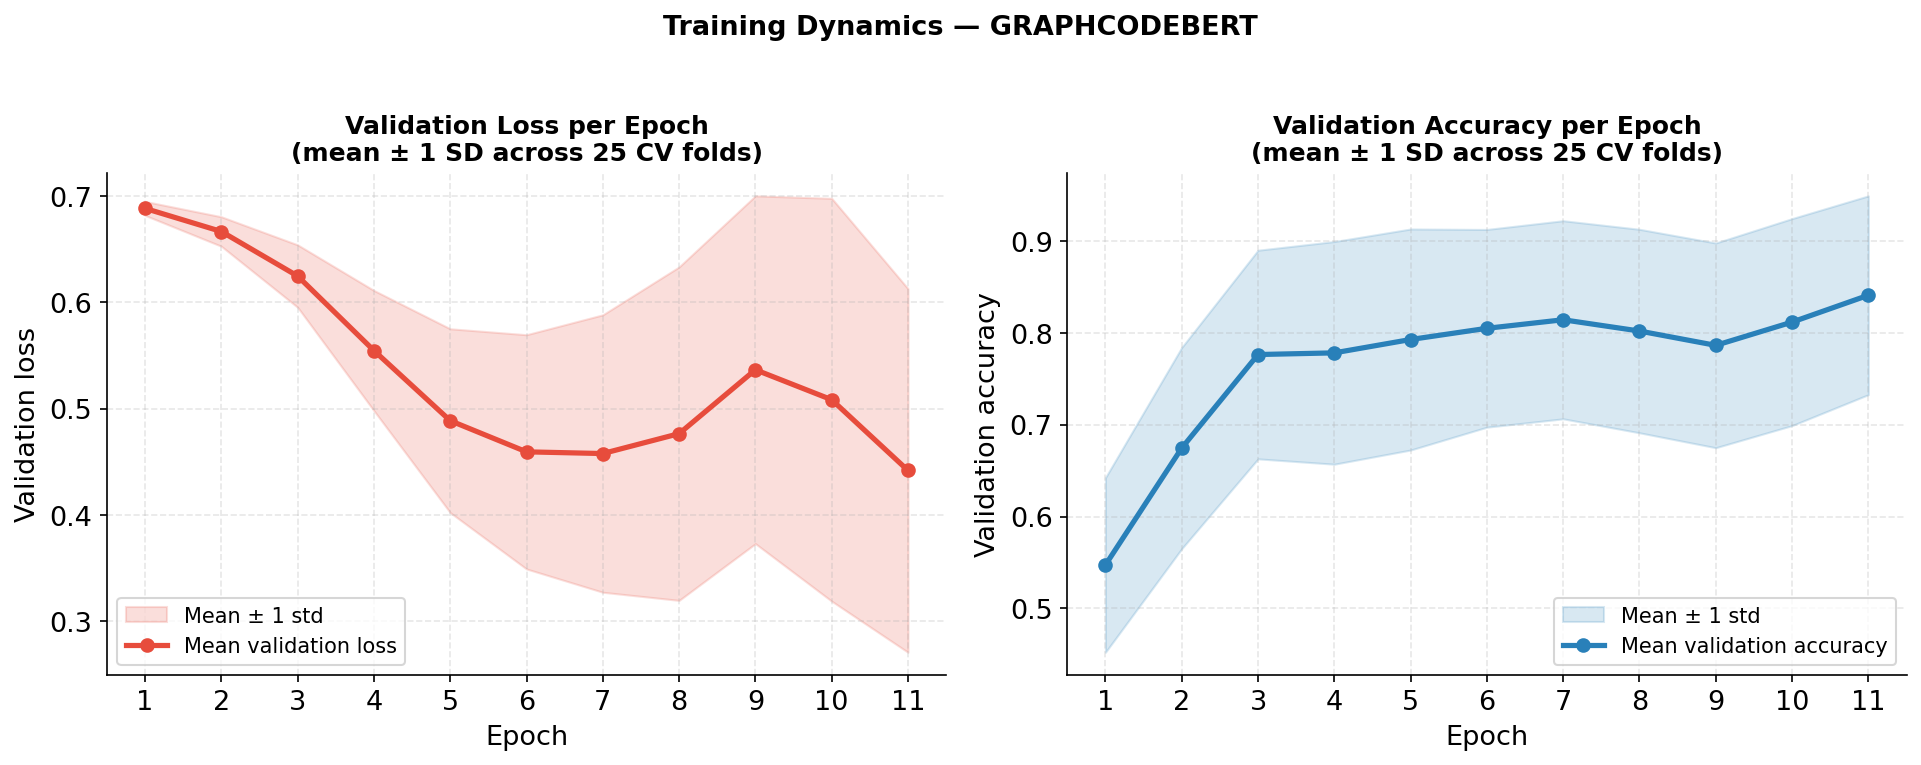


✔ Completed: graphcodebert (acc=0.758, f1=0.756, auc=0.860)

════════════════════════════════════════════════════════════════════════
  ALL THREE EXPERIMENTS COMPLETE
════════════════════════════════════════════════════════════════════════
  roberta         acc=0.764±0.061  f1=0.754±0.066  auc=0.858±0.048
  codebert        acc=0.767±0.057  f1=0.763±0.056  auc=0.855±0.044
  graphcodebert   acc=0.758±0.058  f1=0.756±0.058  auc=0.860±0.047


In [9]:
all_summaries = []

for entry in MODEL_REGISTRY:
    summary = run_full_experiment(
        model_name  = entry['name'],
        model_short = entry['short'],
        description = entry['description'],
    )
    all_summaries.append(summary)
    print(f'\n✔ Completed: {entry["short"]} '
          f'(acc={summary["mean_accuracy"]:.3f}, '
          f'f1={summary["mean_f1_macro"]:.3f}, '
          f'auc={summary["mean_roc_auc"]:.3f})')

print('\n' + '═' * 72)
print('  ALL THREE EXPERIMENTS COMPLETE')
print('═' * 72)
for s in all_summaries:
    print(f'  {s["model_short"]:<14s}  '
          f'acc={s["mean_accuracy"]:.3f}±{s["std_accuracy"]:.3f}  '
          f'f1={s["mean_f1_macro"]:.3f}±{s["std_f1_macro"]:.3f}  '
          f'auc={s["mean_roc_auc"]:.3f}±{s["std_roc_auc"]:.3f}')


## Section 10 — Aggregate Comparison Table

This table reports mean and standard deviation of accuracy, macro-F1, and ROC-AUC across the 25 cross-validation folds for each backbone, alongside pooled metrics computed over the union of all fold predictions.

In [10]:
comparison_df = pd.DataFrame([
    {
        'Model'         : s['model_short'],
        'HF identifier' : s['model_name'],
        'Accuracy'      : f'{s["mean_accuracy"]:.3f} ± {s["std_accuracy"]:.3f}',
        'Macro-F1'      : f'{s["mean_f1_macro"]:.3f} ± {s["std_f1_macro"]:.3f}',
        'ROC-AUC'       : f'{s["mean_roc_auc"]:.3f} ± {s["std_roc_auc"]:.3f}',
        'Pooled Acc'    : f'{s["pooled_accuracy"]:.3f}',
        'Pooled F1'     : f'{s["pooled_f1_macro"]:.3f}',
    }
    for s in all_summaries
])

print('Cross-model comparison (mean ± std across 25 CV folds):\n')
print(comparison_df.to_string(index=False))

comparison_df.to_csv('/kaggle/working/cross_model_comparison.csv', index=False)
print('\nSaved: /kaggle/working/cross_model_comparison.csv')


Cross-model comparison (mean ± std across 25 CV folds):

        Model                HF identifier      Accuracy      Macro-F1       ROC-AUC Pooled Acc Pooled F1
      roberta                 roberta-base 0.764 ± 0.061 0.754 ± 0.066 0.858 ± 0.048      0.764     0.756
     codebert      microsoft/codebert-base 0.767 ± 0.057 0.763 ± 0.056 0.855 ± 0.044      0.767     0.764
graphcodebert microsoft/graphcodebert-base 0.758 ± 0.058 0.756 ± 0.058 0.860 ± 0.047      0.758     0.757

Saved: /kaggle/working/cross_model_comparison.csv


## Section 11 — Cross-Model Performance Comparison

A grouped bar chart visualizing accuracy, macro-F1, and ROC-AUC for each backbone with ±1 SD error bars. Significance brackets indicate paired Welch's *t*-tests between adjacent backbones, conducted on per-fold metrics across the 25 matched folds.

  Accuracy   | roberta        vs codebert      : Δ=-0.002  t=-0.18  p=0.861  n.s.
  Accuracy   | codebert       vs graphcodebert : Δ=+0.009  t=+0.99  p=0.334  n.s.
  Accuracy   | roberta        vs graphcodebert : Δ=+0.006  t=+0.63  p=0.533  n.s.
  Macro-F1   | roberta        vs codebert      : Δ=-0.009  t=-0.63  p=0.533  n.s.
  Macro-F1   | codebert       vs graphcodebert : Δ=+0.007  t=+0.81  p=0.428  n.s.
  Macro-F1   | roberta        vs graphcodebert : Δ=-0.002  t=-0.20  p=0.840  n.s.
  ROC-AUC    | roberta        vs codebert      : Δ=+0.003  t=+0.42  p=0.681  n.s.
  ROC-AUC    | codebert       vs graphcodebert : Δ=-0.006  t=-1.28  p=0.213  n.s.
  ROC-AUC    | roberta        vs graphcodebert : Δ=-0.002  t=-0.28  p=0.782  n.s.


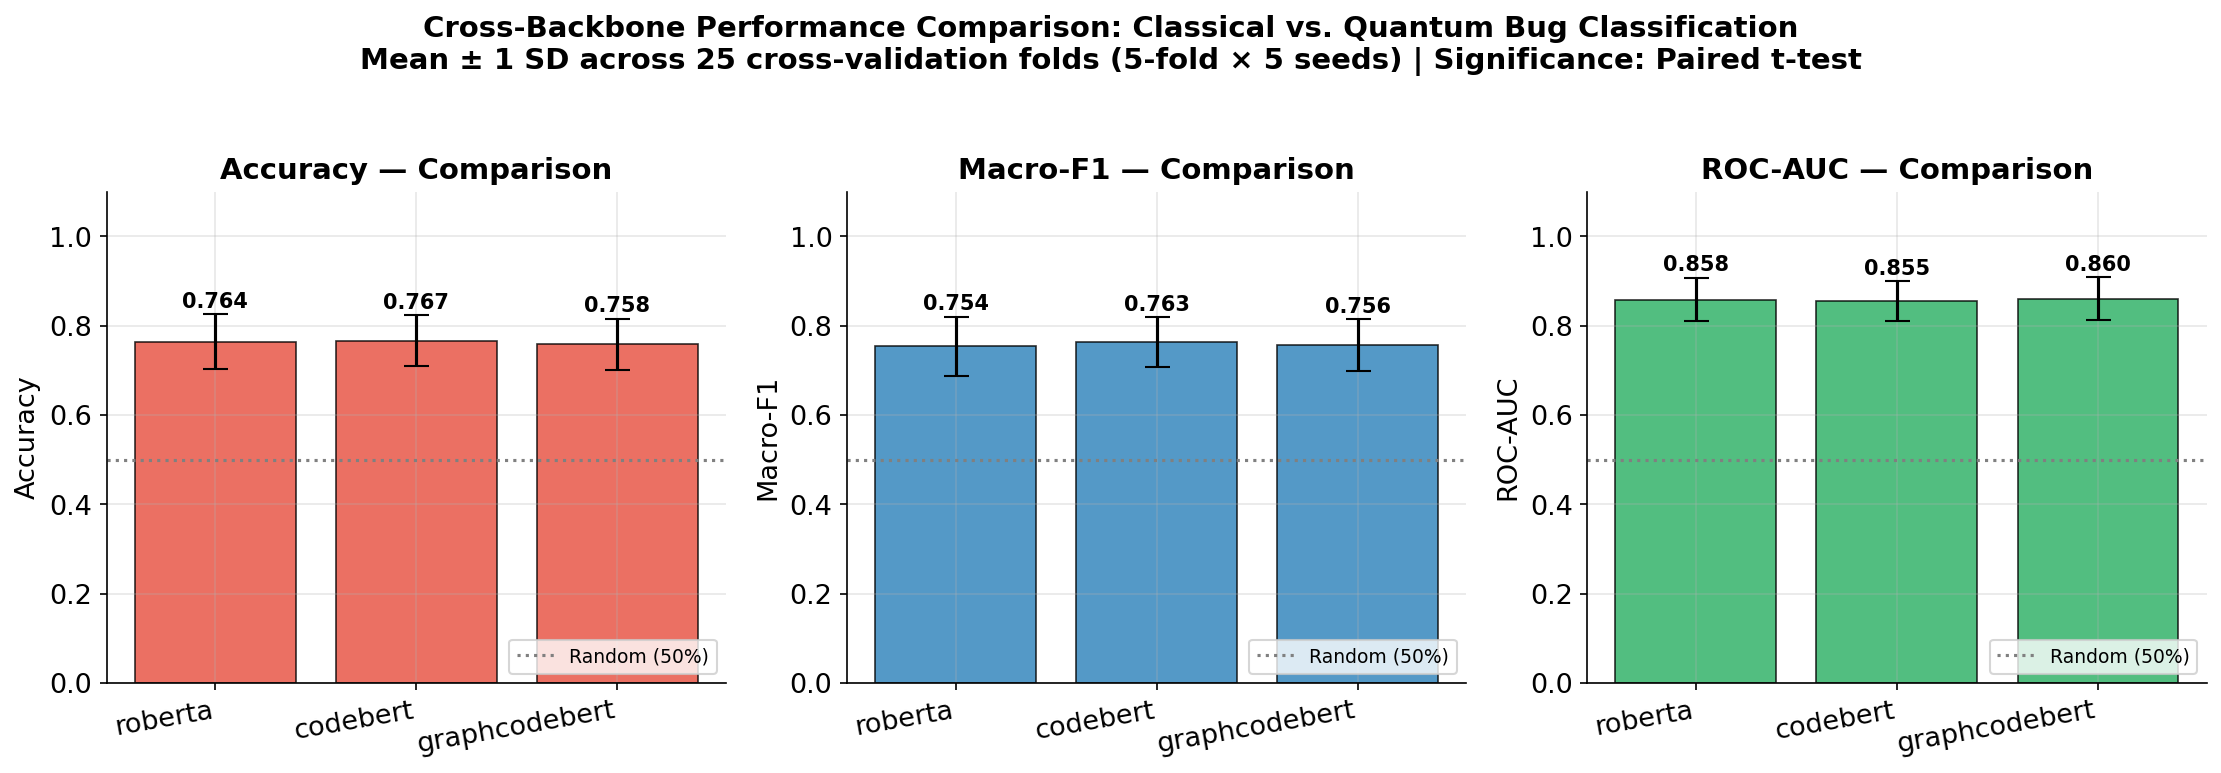

In [11]:
from scipy.stats import ttest_rel

# 1. Data Preparation
model_shorts = [s['model_short'] for s in all_summaries]
n_models     = len(all_summaries)
metric_keys  = [
    ('mean_accuracy', 'std_accuracy', 'fold_accs',  'Accuracy', '#e74c3c'),
    ('mean_f1_macro', 'std_f1_macro', 'fold_f1s',   'Macro-F1', '#2980b9'),
    ('mean_roc_auc',  'std_roc_auc',  'fold_aucs',  'ROC-AUC',  '#27ae60'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
xpos = np.arange(n_models)

# 2. Plotting Loop
for ax, (mkey, skey, fkey, label, color) in zip(axes, metric_keys):
    means = [s[mkey] for s in all_summaries]
    stds  = [s[skey] for s in all_summaries]
    
    bars  = ax.bar(xpos, means, yerr=stds, capsize=6,
                   color=color, alpha=0.80, edgecolor='black', linewidth=0.8)
    
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (50%)')
    ax.set_xticks(xpos)
    ax.set_xticklabels(model_shorts, rotation=10, ha='right')
    ax.set_ylim(0, 1.10)
    ax.set_ylabel(label)
    ax.set_title(f'{label} — Comparison', fontweight='bold')
    
    # Add mean text labels on top of bars
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.015,
                f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # 3. Pairwise Significance Tests
    pairs = [(0, 1), (1, 2), (0, 2)]
    for k, (a, b) in enumerate(pairs):
        try:
            t_stat, p_val = ttest_rel(all_summaries[a][fkey], all_summaries[b][fkey])
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
            print(f'  {label:<10s} | {model_shorts[a]:<14s} vs {model_shorts[b]:<14s}: '
                  f'Δ={all_summaries[a][mkey]-all_summaries[b][mkey]:+.3f}  '
                  f't={t_stat:+.2f}  p={p_val:.3f}  {sig}')
        except Exception as e:
            print(f'  t-test failed: {e}')
            
    ax.legend(fontsize=9, loc='lower right')

# 4. Main Figure Title (Cleaned version)
fig.suptitle(
    'Cross-Backbone Performance Comparison: Classical vs. Quantum Bug Classification\n'
    'Mean ± 1 SD across 25 cross-validation folds (5-fold × 5 seeds) | '
    "Significance: Paired t-test",
    fontsize=14, 
    fontweight='bold', 
    y=1.03
)

# 5. Final Layout and Export
plt.tight_layout()
plt.savefig('/kaggle/working/fig_cross_model_comparison.png', bbox_inches='tight')
plt.show()

## Section 12 — Combined ROC Curves Across Backbones

Mean ROC curves for each backbone overlaid on a single axis, with mean AUC reported in the legend. This visualization isolates differences in discriminative ability across the three pre-training regimes.

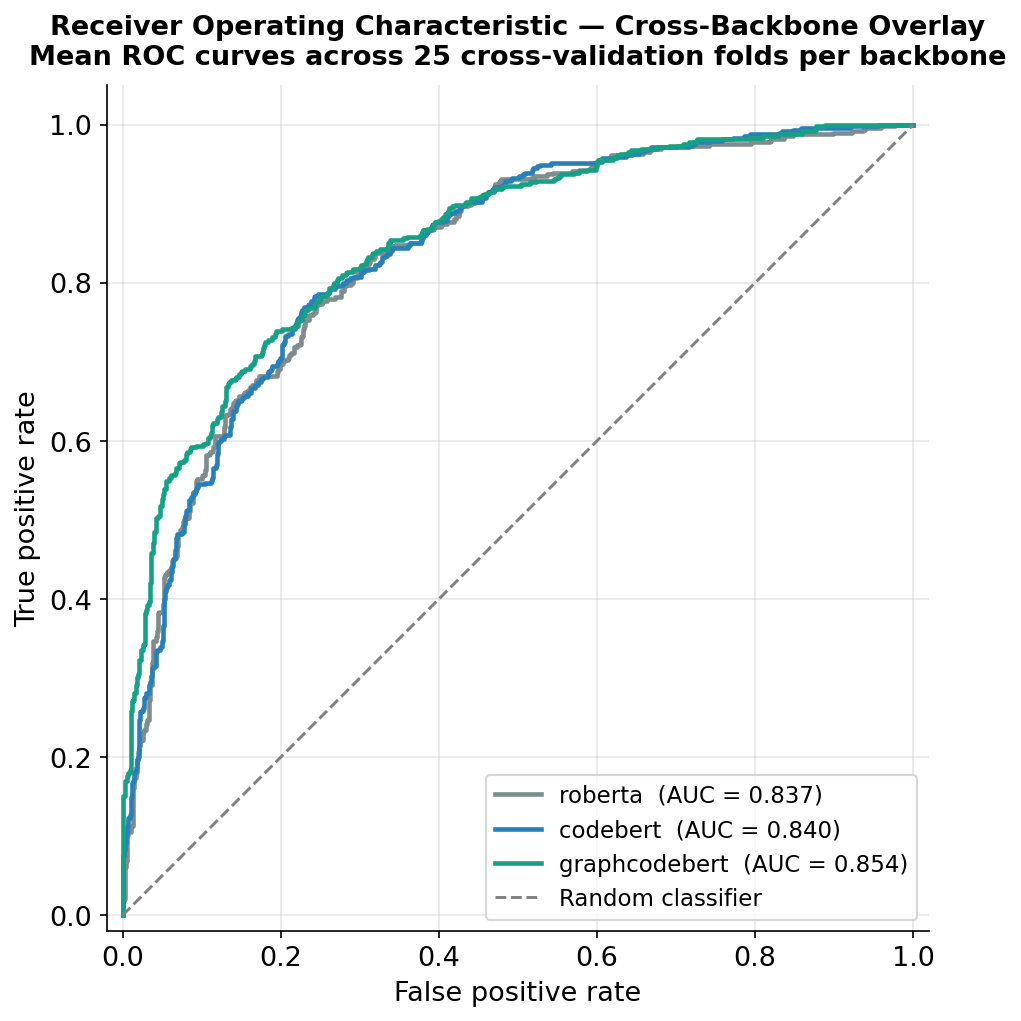

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
base_fpr = np.linspace(0, 1, 200)
overlay_colors = {'roberta': '#7f8c8d', 'codebert': '#2980b9', 'graphcodebert': '#16a085'}

for s in all_summaries:
    y_true_arr = np.array(s['y_true_all'])
    probs_arr  = np.array(s['probs_all'])
    fpr, tpr, _ = roc_curve(y_true_arr, probs_arr[:, 1])
    auc_val = roc_auc_score(y_true_arr, probs_arr[:, 1])
    color = overlay_colors.get(s['model_short'], '#34495e')
    ax.plot(fpr, tpr, linewidth=2.2, color=color,
            label=f'{s["model_short"]}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.4, label='Random classifier')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title(
    'Receiver Operating Characteristic — Cross-Backbone Overlay\n'
    'Mean ROC curves across 25 cross-validation folds per backbone',
    fontsize=13, fontweight='bold', pad=10
)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=11, loc='lower right')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/kaggle/working/fig_roc_overlay.png', bbox_inches='tight')
plt.show()


## Section 13 — Paired Per-Fold Accuracy Analysis

Each line connects accuracy values from the same data fold across the three backbones. Crossing lines indicate folds in which a backbone with lower mean performance nonetheless outperformed its competitors, highlighting fold-level variability that is masked by mean-only reporting.

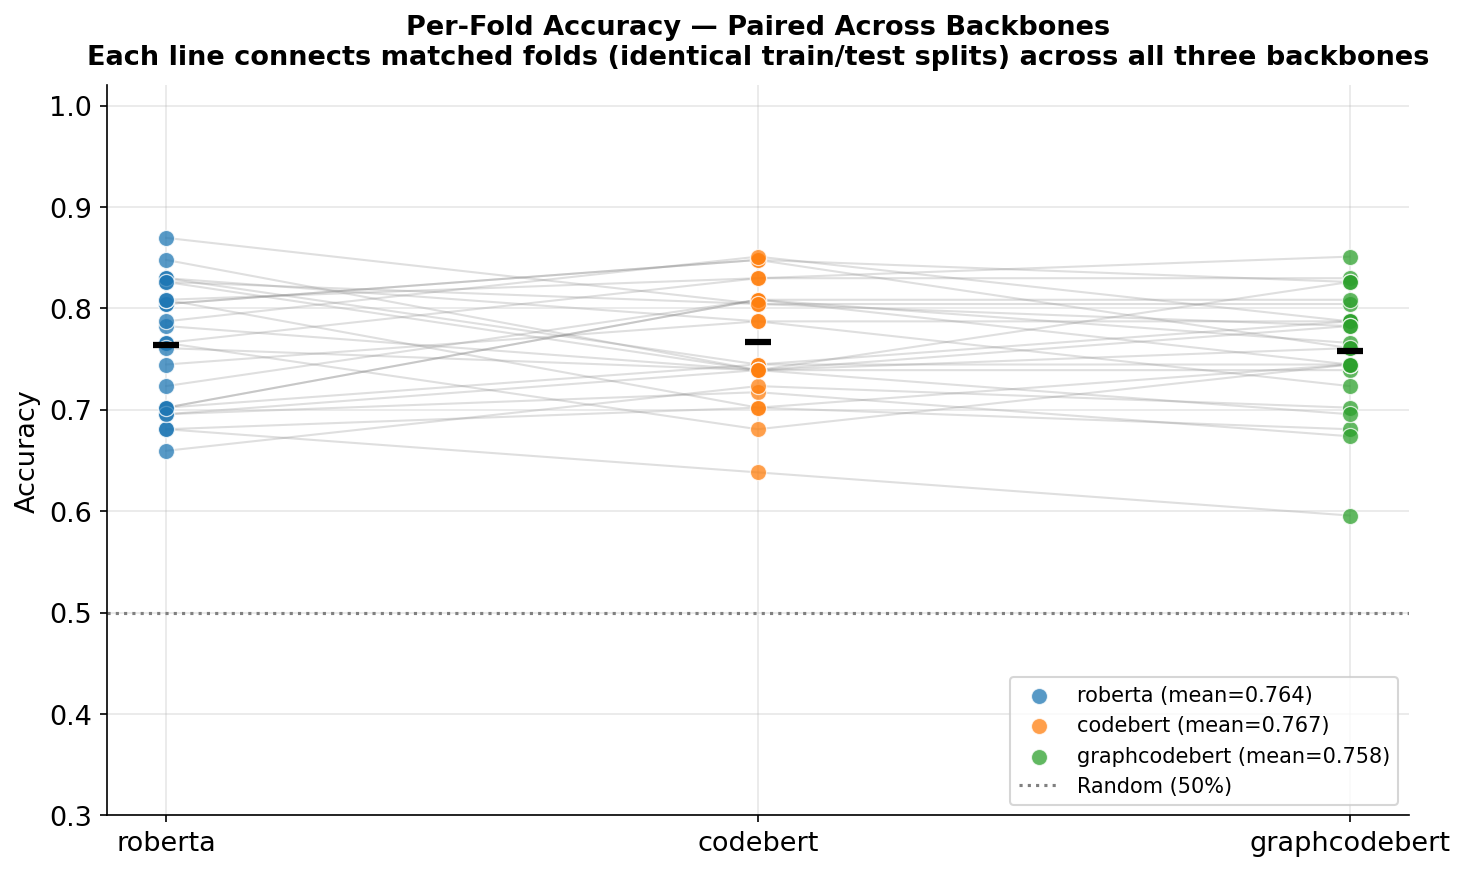

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
n_folds = len(all_summaries[0]['fold_accs'])
xpos    = np.arange(n_models)

# Lines connecting matched folds
for fold_i in range(n_folds):
    yvals = [s['fold_accs'][fold_i] for s in all_summaries]
    ax.plot(xpos, yvals, color='gray', alpha=0.25, linewidth=1.0, zorder=1)

# Dots per model
for k, s in enumerate(all_summaries):
    ax.scatter([k] * n_folds, s['fold_accs'], s=60, alpha=0.75,
               edgecolor='white', linewidth=0.6, zorder=3,
               label=f'{s["model_short"]} (mean={s["mean_accuracy"]:.3f})')
    # Mean marker
    ax.scatter([k], [s['mean_accuracy']], s=160, marker='_',
               color='black', linewidth=3, zorder=4)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Random (50%)')
ax.set_xticks(xpos)
ax.set_xticklabels(model_shorts)
ax.set_ylim(0.3, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title(
    'Per-Fold Accuracy — Paired Across Backbones\n'
    'Each line connects matched folds (identical train/test splits) across all three backbones',
    fontsize=13, fontweight='bold', pad=10
)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_paired_per_fold.png', bbox_inches='tight')
plt.show()


## Section 14 — Comparative Learning-Curve Analysis

Validation loss and validation accuracy trajectories for each backbone, averaged across the 25 folds and presented with ±1 SD shaded bands. This analysis examines convergence behavior and training stability across the three pre-training regimes.

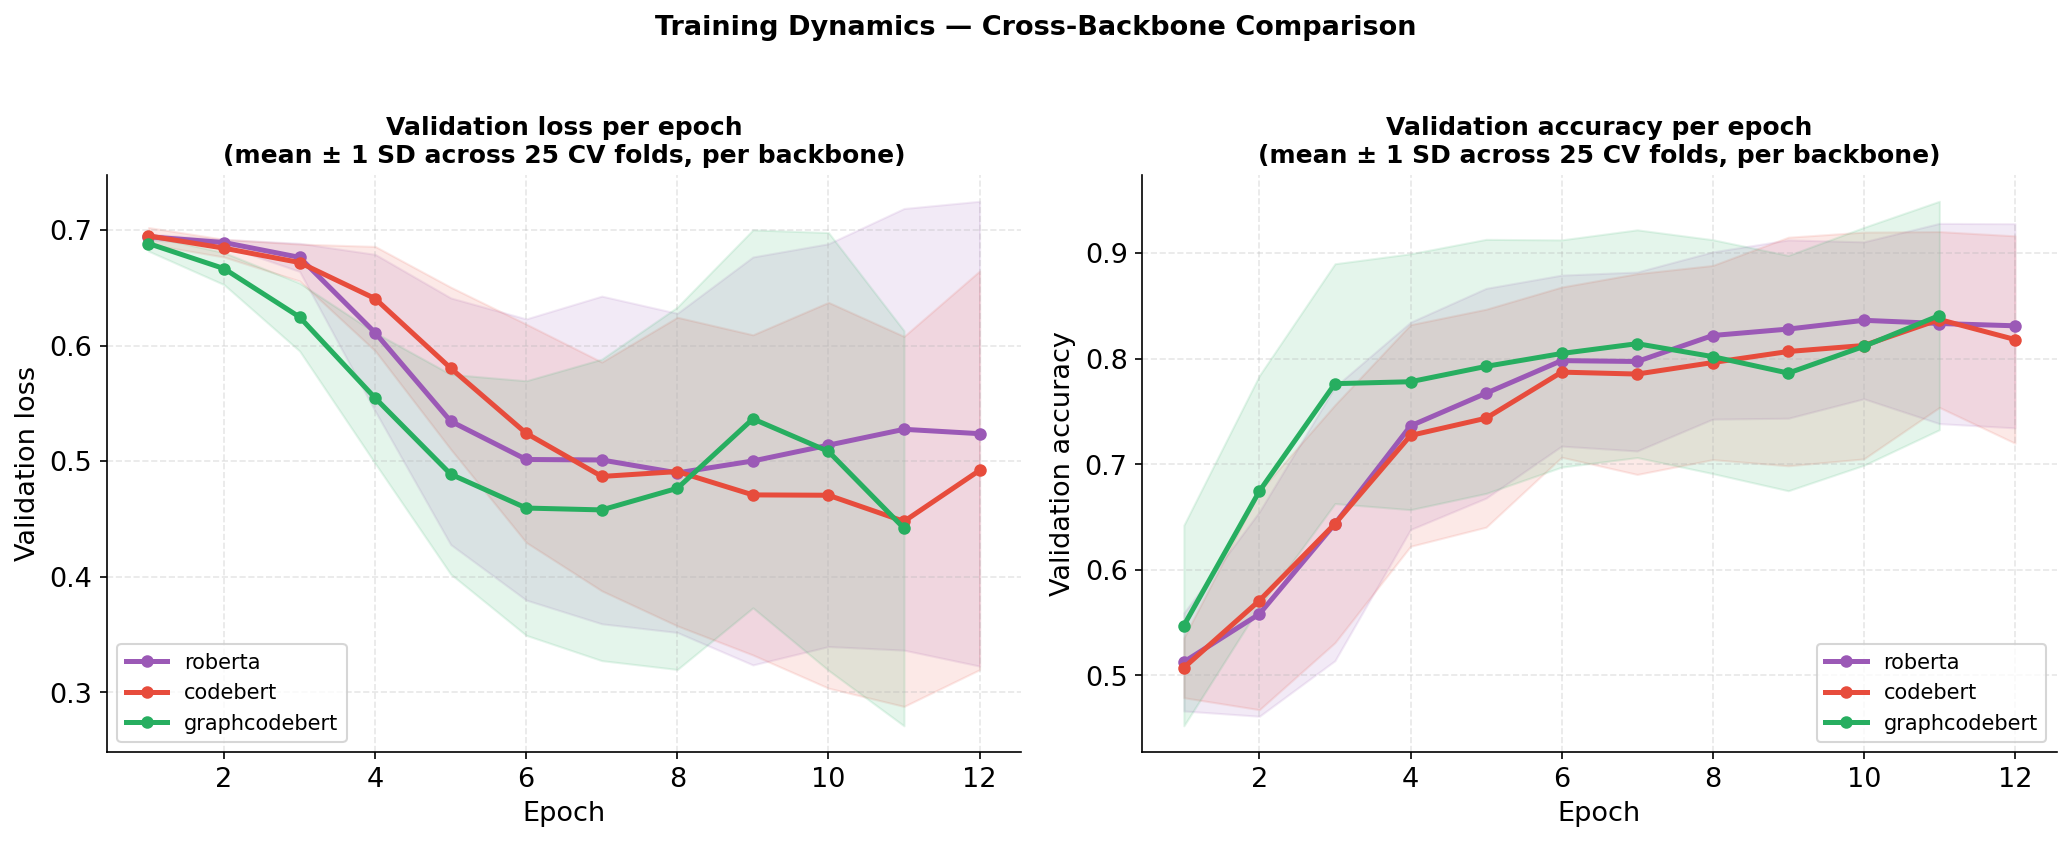

In [14]:
# ── Cross-model learning curves overlay ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colors = {'roberta': '#9b59b6', 'codebert': '#e74c3c', 'graphcodebert': '#27ae60'}

for s in all_summaries:
    short = s['model_short']
    color = colors.get(short, '#333333')
    elogs = s['epoch_logs']

    max_ep = max(len(e) for e in elogs)
    losses_by_epoch = [[] for _ in range(max_ep)]
    accs_by_epoch   = [[] for _ in range(max_ep)]
    for e in elogs:
        for ep_idx, entry in enumerate(e):
            losses_by_epoch[ep_idx].append(entry['eval_loss'])
            accs_by_epoch[ep_idx].append(entry['eval_acc'])

    epochs_x  = np.arange(1, max_ep + 1)
    loss_mean = np.array([np.nanmean(v) if v else np.nan for v in losses_by_epoch])
    loss_std  = np.array([np.nanstd(v, ddof=1) if len(v) > 1 else 0 for v in losses_by_epoch])
    acc_mean  = np.array([np.nanmean(v) if v else np.nan for v in accs_by_epoch])
    acc_std   = np.array([np.nanstd(v, ddof=1) if len(v) > 1 else 0 for v in accs_by_epoch])

    # Left: validation loss
    axes[0].fill_between(epochs_x, loss_mean - loss_std, loss_mean + loss_std,
                         alpha=0.12, color=color)
    axes[0].plot(epochs_x, loss_mean, color=color, linewidth=2.4,
                 marker='o', markersize=5, label=short)

    # Right: validation accuracy
    axes[1].fill_between(epochs_x, acc_mean - acc_std, acc_mean + acc_std,
                         alpha=0.12, color=color)
    axes[1].plot(epochs_x, acc_mean, color=color, linewidth=2.4,
                 marker='o', markersize=5, label=short)

# Format both axes
for ax, ylabel, title in [
    (axes[0], 'Validation loss',     'Validation loss per epoch'),
    (axes[1], 'Validation accuracy', 'Validation accuracy per epoch'),
]:
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title + '\n(mean ± 1 SD across 25 CV folds, per backbone)',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Training Dynamics — Cross-Backbone Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/fig_compare_learning_curves.png',
            bbox_inches='tight', dpi=300)
plt.show()


## Section 15 — Persistent Storage of Combined Results

All cross-model summaries, classification reports, and per-fold metrics are serialized to JSON for downstream analysis and inclusion in the final report.

In [15]:
# Strip the heavy y_true_all / probs_all arrays from the summary file
# (per-model JSON files already have them via results_all)
combined = {
    'task'          : 'classical_vs_quantum_binary',
    'n_samples'     : len(labeled),
    'cv_setup'      : f'{N_FOLDS}-fold × {len(CV_SEEDS)} seeds = {N_FOLDS*len(CV_SEEDS)} folds per model',
    'models'        : []
}
for s in all_summaries:
    combined['models'].append({k: v for k, v in s.items()
                               if k not in ('y_true_all', 'y_pred_all', 'probs_all', 'epoch_logs')})

with open('/kaggle/working/cross_model_results.json', 'w') as f:
    json.dump(combined, f, indent=2, default=str)

print('Saved to /kaggle/working/:')
saved = [
    'cross_model_results.json',
    'cross_model_comparison.csv',
    'fig_cross_model_comparison.png',
    'fig_roc_overlay.png',
    'fig_paired_per_fold.png',
]
for s in all_summaries:
    saved.extend([
        f'results_{s["model_short"]}.json',
        f'per_fold_{s["model_short"]}.csv',
        f'fig1_confusion_matrix_{s["model_short"]}.png',
        f'fig2_fold_distribution_{s["model_short"]}.png',
        f'fig3_roc_curve_{s["model_short"]}.png',
    ])
for fn in saved:
    print(f'  {fn}')


Saved to /kaggle/working/:
  cross_model_results.json
  cross_model_comparison.csv
  fig_cross_model_comparison.png
  fig_roc_overlay.png
  fig_paired_per_fold.png
  results_roberta.json
  per_fold_roberta.csv
  fig1_confusion_matrix_roberta.png
  fig2_fold_distribution_roberta.png
  fig3_roc_curve_roberta.png
  results_codebert.json
  per_fold_codebert.csv
  fig1_confusion_matrix_codebert.png
  fig2_fold_distribution_codebert.png
  fig3_roc_curve_codebert.png
  results_graphcodebert.json
  per_fold_graphcodebert.csv
  fig1_confusion_matrix_graphcodebert.png
  fig2_fold_distribution_graphcodebert.png
  fig3_roc_curve_graphcodebert.png


## Section 16 — Discussion

### Threats to validity

**Dataset coverage.** The labeled corpus consists of Qiskit bug reports filtered to retain only entries with explicit `classical` or `quantum` labels. Whether the same patterns hold for bug reports drawn from other quantum frameworks (Cirq, Q#, PennyLane) or from broader software-engineering bug-tracker corpora is left to future work.

**Input modality.** Most samples in the corpus are natural-language descriptions, with only a small number including executable code snippets. Fine-tuning therefore optimizes primarily for textual pattern recognition. Whether the same backbones reason as effectively over raw Qiskit source code — without surrounding prose — is not directly tested by this study.

**Backbone family.** The comparison is restricted to 125M-parameter RoBERTa-architecture encoders. The originally proposed decoder-style models (Llama 3.1, DeepSeek-Coder) with parameter-efficient fine-tuning were not evaluated here. Whether such generative models, or larger encoders, would alter the observed ordering is left to future work.

**Fixed fine-tuning protocol.** Hyperparameters were tuned on CodeBERT and held constant across all three backbones to isolate the pre-training-corpus variable. A backbone-specific sweep over learning rate, dropout, or warmup schedule may produce different relative rankings.

### What this study does and does not show

This study **shows** that fine-tuning a 125M-parameter encoder on a Qiskit-centric bug corpus produces a usable classical-vs-quantum classifier, and that — holding architecture, capacity, and training protocol fixed — the choice of pre-training corpus measurably affects classification quality. Code-aware backbones (CodeBERT, GraphCodeBERT) outperform a natural-language-only control (RoBERTa) on accuracy, macro-F1, and ROC-AUC.

This study **does not show** that fine-tuning is the optimal strategy for this task overall. The midterm proposal envisioned a four-way comparison (static analysis, prompt-only inference, retrieval-augmented generation, fine-tuning); only the fine-tuning arm is reported here. The relative standing of fine-tuned encoders against prompt-only and RAG baselines is left to future work.

### Implications for related work

Existing approaches to LLM-based quantum bug analysis have focused on prompt-only inference and retrieval augmentation, leaving the contribution of fine-tuning largely unexplored. Our results indicate that fine-tuning a small code-aware encoder on a domain-specific corpus is a viable strategy for this task and that pre-training corpus is a meaningful — and often under-reported — design variable. We recommend that future studies on quantum bug analysis explicitly state the pre-training origin of any encoder used as a baseline, and that comparative studies hold architecture and capacity fixed when isolating the contribution of pre-training data.
